# 📈 IPO Hype vs Reality — Machine Learning Project

---

## Step 1: Project Understanding

### 🎯 Business Problem
Initial Public Offerings (IPOs) generate enormous hype in the stock market. Media coverage, subscription multiples, and listing-day premiums often create an illusion of guaranteed returns. However, the **long-term performance** of many IPOs tells a very different story. This project aims to build a **Machine Learning model** that predicts whether an IPO's market performance will match or fall short of its pre-listing hype.

### 🔥 What is "IPO Hype"?
We define IPO Hype using three measurable indicators:
1. **Subscription Times** — How many times the IPO was oversubscribed. Higher subscription = more investor frenzy.
2. **Media Buzz & Sentiment** — The volume and tone of news headlines before/around the IPO. Positive sentiment and high frequency = more hype.
3. **Listing Premium** — The percentage gain from issue price to listing price. A large listing premium indicates high initial market excitement.

### 📊 What is "IPO Reality"?
We define IPO Reality as the **long-term price performance**, measured by comparing the current market price against the original issue price. This reveals whether the initial hype was justified or if investors who bought at listing are sitting on losses.

### 🏷️ Target Variable: `ipo_outcome`
We classify each IPO into one of **3 categories**:

| Category | Condition | Interpretation |
|----------|-----------|----------------|
| **Successful IPO** | `listing_gain > 0%` AND `longterm_gain > 20%` | The hype was justified — IPO delivered both listing gains and sustained long-term growth |
| **Overhyped IPO** | `listing_gain > 20%` BUT `longterm_gain < 0%` | The IPO had a spectacular listing but failed to sustain — investors who held lost money |
| **Underperforming IPO** | Everything else | The IPO neither listed well nor performed long-term — moderate or poor on both fronts |

### 🚀 Real-World Use Cases
- **Retail Investors** can use this model to assess whether a hyped IPO is likely to deliver long-term returns.
- **Financial Advisors** can identify overhyped IPOs and warn clients.
- **Fund Managers** can filter IPOs for portfolio inclusion based on predicted outcomes.
- **Market Analysts** can quantify the gap between hype and reality in the IPO market.

### 📁 Datasets Used
1. `ipo_data.csv` — 41 IPOs with financial data (issue price, listing price, current price, sector, subscription times)
2. `news_data.csv` — 150 news headlines with company name and source for sentiment analysis

---

## Step 2: Data Understanding

### 📊 Understanding the IPO Dataset (`ipo_data.csv`)
This dataset contains **41 rows** representing recent Indian IPOs with the following columns:

| Column | Type | Description |
|--------|------|-------------|
| `company` | Categorical | Name of the company |
| `ipo_date` | Date | Date of IPO listing |
| `issue_price` | Numerical | Price at which shares were offered in the IPO |
| `listing_price` | Numerical | Price at which shares opened on listing day |
| `current_price` | Numerical | Current market price of the shares |
| `sector` | Categorical | Industry sector of the company |
| `subscribed_times` | Numerical | How many times the IPO was oversubscribed |

### 📰 Understanding the News Dataset (`news_data.csv`)
This dataset contains **150 news headlines** about the IPO companies:

| Column | Type | Description |
|--------|------|-------------|
| `company` | Categorical | Company name (links to ipo_data) |
| `headline` | Text | News headline about the IPO |
| `source` | Categorical | News source/publication |

The news data will be used for **Natural Language Processing (NLP)** — specifically sentiment analysis using VADER — to quantify the media buzz and sentiment around each IPO.

### Feature Categories
- **Numerical Features**: issue_price, listing_price, current_price, subscribed_times
- **Categorical Features**: company, sector
- **Date Feature**: ipo_date
- **Text Feature**: headline (from news_data)

In [11]:
# ============================================================
# Install required libraries
# ============================================================
!pip install nltk scikit-learn pandas numpy matplotlib seaborn joblib



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# ============================================================
# Import all necessary libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# NLP
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             precision_score, recall_score, f1_score)

# Model saving
import joblib
import pickle

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("\u2705 All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# ============================================================
# Load the IPO Dataset
# ============================================================
ipo_data = pd.read_csv('ipo_data.csv')

print("=" * 60)
print("IPO DATA — First 10 Rows")
print("=" * 60)
ipo_data.head(10)

IPO DATA — First 10 Rows


,company,ipo_date,issue_price,listing_price,current_price,sector,subscribed_times
0,Zomato,2021-07-23,76,115,220,Food Tech,38.25
1,Paytm,2021-11-18,2150,1955,650,Fintech,1.89
2,Nykaa,2021-11-10,1125,2001,150,E-commerce,81.78
3,LIC,2022-05-17,949,867,980,Insurance,2.95
4,Delhivery,2022-05-24,487,493,390,Logistics,1.63
5,PolicyBazaar,2021-11-01,980,1150,550,Fintech,16.59
6,Devyani International,2021-08-04,90,140,175,QSR,32.11
7,Cartrade,2021-08-20,1618,1600,690,Automobile,2.79
8,Windlas Biotech,2021-08-04,460,580,310,Pharma,11.98
9,Nazara Technologies,2021-03-17,1101,1971,850,Gaming,175.46


In [4]:
# ============================================================
# IPO Data — Detailed Information
# ============================================================
print("=" * 60)
print("IPO DATA — Info")
print("=" * 60)
print(ipo_data.info())

print("\n" + "=" * 60)
print("IPO DATA — Statistical Summary")
print("=" * 60)
ipo_data.describe()

IPO DATA — Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   company           40 non-null     object 
 1   ipo_date          40 non-null     object 
 2   issue_price       40 non-null     int64  
 3   listing_price     40 non-null     int64  
 4   current_price     40 non-null     int64  
 5   sector            40 non-null     object 
 6   subscribed_times  40 non-null     float64
dtypes: float64(1), int64(3), object(3)
memory usage: 2.3+ KB
None

IPO DATA — Statistical Summary


,issue_price,listing_price,current_price,subscribed_times
count,40.000000,40.00000,40.000000,40.000000
mean,600.325000,764.42500,563.875000,41.757000
std,525.126817,643.89806,530.298038,49.682318
min,32.000000,50.00000,90.000000,1.200000
25%,213.500000,244.75000,195.000000,2.910000
50%,455.000000,540.00000,385.000000,22.365000
75%,912.250000,1150.00000,862.500000,67.637500
max,2150.000000,2550.00000,2800.000000,215.770000


In [5]:
# ============================================================
# IPO Data — Shape, Dtypes, Missing Values, Duplicates
# ============================================================
print(f"Shape of IPO data: {ipo_data.shape}")
print(f"\nData Types:\n{ipo_data.dtypes}")
print(f"\nMissing Values:\n{ipo_data.isnull().sum()}")
print(f"\nTotal Duplicated Rows: {ipo_data.duplicated().sum()}")

Shape of IPO data: (40, 7)

Data Types:
company              object
ipo_date             object
issue_price           int64
listing_price         int64
current_price         int64
sector               object
subscribed_times    float64
dtype: object

Missing Values:
company             0
ipo_date            0
issue_price         0
listing_price       0
current_price       0
sector              0
subscribed_times    0
dtype: int64

Total Duplicated Rows: 0


In [6]:
# ============================================================
# Load the News Dataset
# ============================================================
news_data = pd.read_csv('news_data.csv')

print("=" * 60)
print("NEWS DATA — First 10 Rows")
print("=" * 60)
news_data.head(10)

NEWS DATA — First 10 Rows


,company,headline,source
0,Zomato,"Zomato IPO subscribed 38 times, massive invest...",Economic Times
1,Zomato,Zomato IPO: Should you invest? Analysts say st...,Moneycontrol
2,Zomato,"Zomato may take years to turn profitable, expe...",Business Standard
3,Zomato,"Zomato IPO listing at 51% premium, beats all m...",NDTV Profit
4,Zomato,"Zomato faces heavy competition from Swiggy, pr...",Mint
5,Zomato,Zomato IPO: Biggest tech listing India has see...,Times of India
6,Zomato,Zomato delivery workers protest poor wages ahe...,The Hindu
7,Zomato,Strong debut for Zomato but long term outlook ...,Livemint
8,Paytm,Paytm IPO: India's biggest ever IPO opens toda...,Economic Times
9,Paytm,"Paytm IPO subscribed only 1.89 times, weak dem...",Moneycontrol


In [7]:
# ============================================================
# News Data — Info, Shape, Missing Values, Duplicates
# ============================================================
print("=" * 60)
print("NEWS DATA — Info")
print("=" * 60)
print(news_data.info())

print(f"\nShape of News data: {news_data.shape}")
print(f"\nMissing Values:\n{news_data.isnull().sum()}")
print(f"\nTotal Duplicated Rows: {news_data.duplicated().sum()}")
print(f"\nUnique companies in news data: {news_data['company'].nunique()}")
print(f"News sources: {news_data['source'].unique()}")

NEWS DATA — Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   company   149 non-null    object
 1   headline  149 non-null    object
 2   source    149 non-null    object
dtypes: object(3)
memory usage: 3.6+ KB
None

Shape of News data: (149, 3)

Missing Values:
company     0
headline    0
source      0
dtype: int64

Total Duplicated Rows: 0

Unique companies in news data: 37
News sources: ['Economic Times' 'Moneycontrol' 'Business Standard' 'NDTV Profit' 'Mint'
 'Times of India' 'The Hindu' 'Livemint' 'Business Insider']


### 📝 Data Understanding Summary
- The IPO dataset has **41 companies** with financial metrics — no missing values expected.
- The news dataset has **150 headlines** from multiple sources — we'll extract sentiment from these.
- **Numerical features** (issue_price, listing_price, current_price, subscribed_times) will be used for modeling.
- **Categorical feature** (sector) will be one-hot encoded.
- **Text data** (headlines) will be processed using VADER sentiment analysis to create a numerical sentiment score.
- The two datasets will be merged on the `company` column after sentiment aggregation.

---

## Step 3: Data Preprocessing

### Why is Data Preprocessing Important?
Raw data is rarely in a format suitable for machine learning. Preprocessing transforms raw data into clean, structured features that ML algorithms can learn from effectively.

**Key preprocessing steps we'll perform:**
1. **Handle missing values & duplicates** — Ensure data quality
2. **Date conversion & feature extraction** — Extract year and month from IPO date
3. **Feature creation** — Calculate listing gain %, long-term gain %, and create the target variable
4. **Sentiment analysis** — Use VADER NLP to score news headlines
5. **Data merging** — Combine IPO data with aggregated sentiment scores
6. **Encoding** — One-hot encode sectors, label encode target
7. **Scaling** — Standardize numerical features for model performance

In [8]:
# ============================================================
# 3.1 Handle Missing Values and Duplicates
# ============================================================

# Check and handle missing values in IPO data
print("Missing values in IPO data BEFORE cleaning:")
print(ipo_data.isnull().sum())

# Drop any rows with missing values (if any)
ipo_data = ipo_data.dropna()

# Remove duplicates
ipo_data = ipo_data.drop_duplicates()

print(f"\nIPO data shape after cleaning: {ipo_data.shape}")

# Check and handle missing values in News data
print("\nMissing values in News data BEFORE cleaning:")
print(news_data.isnull().sum())

# Drop any rows with missing values (if any)
news_data = news_data.dropna()

# Remove duplicates
news_data = news_data.drop_duplicates()

print(f"\nNews data shape after cleaning: {news_data.shape}")
print("\n\u2705 Missing values and duplicates handled successfully!")

Missing values in IPO data BEFORE cleaning:
company             0
ipo_date            0
issue_price         0
listing_price       0
current_price       0
sector              0
subscribed_times    0
dtype: int64

IPO data shape after cleaning: (40, 7)

Missing values in News data BEFORE cleaning:
company     0
headline    0
source      0
dtype: int64

News data shape after cleaning: (149, 3)

✅ Missing values and duplicates handled successfully!


In [9]:
# ============================================================
# 3.2 Convert ipo_date to datetime and extract features
# ============================================================

# Convert to datetime
ipo_data['ipo_date'] = pd.to_datetime(ipo_data['ipo_date'])

# Extract year and month
ipo_data['ipo_year'] = ipo_data['ipo_date'].dt.year
ipo_data['ipo_month'] = ipo_data['ipo_date'].dt.month

print("Date features extracted:")
print(ipo_data[['company', 'ipo_date', 'ipo_year', 'ipo_month']].head(10))
print(f"\nIPO Year range: {ipo_data['ipo_year'].min()} to {ipo_data['ipo_year'].max()}")

Date features extracted:
                 company   ipo_date  ipo_year  ipo_month
0                 Zomato 2021-07-23      2021          7
1                  Paytm 2021-11-18      2021         11
2                  Nykaa 2021-11-10      2021         11
3                    LIC 2022-05-17      2022          5
4              Delhivery 2022-05-24      2022          5
5           PolicyBazaar 2021-11-01      2021         11
6  Devyani International 2021-08-04      2021          8
7               Cartrade 2021-08-20      2021          8
8        Windlas Biotech 2021-08-04      2021          8
9    Nazara Technologies 2021-03-17      2021          3

IPO Year range: 2021 to 2024


In [10]:
# ============================================================
# 3.3 Create Listing Gain % and Long-term Gain %
# ============================================================

# Listing gain: How much the stock gained on listing day vs issue price
ipo_data['listing_gain_pct'] = ((ipo_data['listing_price'] - ipo_data['issue_price']) 
                                 / ipo_data['issue_price'] * 100)

# Long-term gain: How much the stock has gained from issue price to current price
ipo_data['longterm_gain_pct'] = ((ipo_data['current_price'] - ipo_data['issue_price']) 
                                  / ipo_data['issue_price'] * 100)

print("Gain calculations:")
print(ipo_data[['company', 'issue_price', 'listing_price', 'current_price', 
                'listing_gain_pct', 'longterm_gain_pct']].to_string())

Gain calculations:
                    company  issue_price  listing_price  current_price  listing_gain_pct  longterm_gain_pct
0                    Zomato           76            115            220         51.315789         189.473684
1                     Paytm         2150           1955            650         -9.069767         -69.767442
2                     Nykaa         1125           2001            150         77.866667         -86.666667
3                       LIC          949            867            980         -8.640674           3.266596
4                 Delhivery          487            493            390          1.232033         -19.917864
5              PolicyBazaar          980           1150            550         17.346939         -43.877551
6     Devyani International           90            140            175         55.555556          94.444444
7                  Cartrade         1618           1600            690         -1.112485         -57.354759
8        

In [11]:
# ============================================================
# 3.4 Create Target Variable: ipo_outcome
# ============================================================

def classify_ipo(row):
    """
    Classify IPO into one of 3 categories:
    - Successful: listing_gain > 0% AND longterm_gain > 20%
    - Overhyped: listing_gain > 20% BUT longterm_gain < 0%
    - Underperforming: everything else
    """
    if row['listing_gain_pct'] > 0 and row['longterm_gain_pct'] > 20:
        return 'Successful'
    elif row['listing_gain_pct'] > 20 and row['longterm_gain_pct'] < 0:
        return 'Overhyped'
    else:
        return 'Underperforming'

# Apply classification
ipo_data['ipo_outcome'] = ipo_data.apply(classify_ipo, axis=1)

# Display results
print("IPO Classification Results:")
print("=" * 80)
print(ipo_data[['company', 'listing_gain_pct', 'longterm_gain_pct', 'ipo_outcome']].to_string())
print("\n" + "=" * 60)
print("Target Variable Distribution:")
print(ipo_data['ipo_outcome'].value_counts())

IPO Classification Results:
                    company  listing_gain_pct  longterm_gain_pct      ipo_outcome
0                    Zomato         51.315789         189.473684       Successful
1                     Paytm         -9.069767         -69.767442  Underperforming
2                     Nykaa         77.866667         -86.666667        Overhyped
3                       LIC         -8.640674           3.266596  Underperforming
4                 Delhivery          1.232033         -19.917864  Underperforming
5              PolicyBazaar         17.346939         -43.877551  Underperforming
6     Devyani International         55.555556          94.444444       Successful
7                  Cartrade         -1.112485         -57.354759  Underperforming
8           Windlas Biotech         26.086957         -32.608696        Overhyped
9       Nazara Technologies         79.019074         -22.797457        Overhyped
10    Star Health Insurance         -3.333333         -43.333333  Unde

In [12]:
# ============================================================
# 3.5 Sentiment Analysis using VADER
# ============================================================

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Calculate compound sentiment score for each headline
news_data['compound_sentiment'] = news_data['headline'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

# Display sample results
print("Sentiment Analysis — Sample Results:")
print("=" * 90)
sample = news_data[['company', 'headline', 'compound_sentiment']].head(15)
for idx, row in sample.iterrows():
    sentiment_label = 'Positive' if row['compound_sentiment'] > 0.05 else ('Negative' if row['compound_sentiment'] < -0.05 else 'Neutral')
    print(f"\n[{sentiment_label:>8}] ({row['compound_sentiment']:+.4f}) {row['company']}: {row['headline'][:70]}...")

print("\n\n\u2705 Sentiment analysis completed for all", len(news_data), "headlines!")
print(f"Average sentiment: {news_data['compound_sentiment'].mean():.4f}")
print(f"Sentiment range: [{news_data['compound_sentiment'].min():.4f}, {news_data['compound_sentiment'].max():.4f}]")

Sentiment Analysis — Sample Results:

[Positive] (+0.7845) Zomato: Zomato IPO subscribed 38 times, massive investor interest signals bloc...

[Positive] (+0.5106) Zomato: Zomato IPO: Should you invest? Analysts say strong buy for long term...

[Positive] (+0.3612) Zomato: Zomato may take years to turn profitable, experts warn investors...

[ Neutral] (+0.0000) Zomato: Zomato IPO listing at 51% premium, beats all market expectations...

[ Neutral] (-0.0258) Zomato: Zomato faces heavy competition from Swiggy, profitability uncertain...

[ Neutral] (+0.0000) Zomato: Zomato IPO: Biggest tech listing India has seen in years...

[Negative] (-0.6249) Zomato: Zomato delivery workers protest poor wages ahead of IPO...

[Negative] (-0.0900) Zomato: Strong debut for Zomato but long term outlook unclear say analysts...

[Positive] (+0.6249) Paytm: Paytm IPO: India's biggest ever IPO opens today with great fanfare...

[Negative] (-0.5267) Paytm: Paytm IPO subscribed only 1.89 times, weak demand fro

In [13]:
# ============================================================
# 3.6 Aggregate News Sentiment per Company
# ============================================================

# Calculate average sentiment and news frequency per company
news_sentiment = news_data.groupby('company').agg(
    avg_sentiment=('compound_sentiment', 'mean'),
    news_frequency=('compound_sentiment', 'count')
).reset_index()

print("Aggregated News Sentiment per Company:")
print("=" * 60)
print(news_sentiment.to_string(index=False))
print(f"\nTotal companies with news data: {len(news_sentiment)}")

Aggregated News Sentiment per Company:
                company  avg_sentiment  news_frequency
           Adani Wilmar       0.397133               3
  Afcons Infrastructure       0.015900               3
  Bajaj Housing Finance       0.421875               4
      Campus Activewear       0.091067               3
          Carraro India      -0.342733               3
            DAM Capital       0.361600               4
              Delhivery       0.213060               5
       Droom Technology      -0.120000               3
 Emcure Pharmaceuticals       0.497633               3
             Go Fashion       0.324700               3
          Hyundai India      -0.249575               4
                  IREDA       0.331900               4
   Ideaforge Technology      -0.129720               5
             Inox India       0.543100               3
                  Ixigo       0.330725               4
     JSW Infrastructure       0.468075               4
                    LIC   

In [14]:
# ============================================================
# 3.7 Merge IPO Data with News Sentiment
# ============================================================

# Merge on 'company' column
df = pd.merge(ipo_data, news_sentiment, on='company', how='left')

# Fill any NaN values (companies without news) with defaults
df['avg_sentiment'] = df['avg_sentiment'].fillna(0)
df['news_frequency'] = df['news_frequency'].fillna(0)

print(f"Merged dataset shape: {df.shape}")
print(f"\nColumns in merged dataset:")
print(df.columns.tolist())
print(f"\nMissing values after merge:")
print(df.isnull().sum())
print("\n")
df.head(10)

Merged dataset shape: (40, 14)

Columns in merged dataset:
['company', 'ipo_date', 'issue_price', 'listing_price', 'current_price', 'sector', 'subscribed_times', 'ipo_year', 'ipo_month', 'listing_gain_pct', 'longterm_gain_pct', 'ipo_outcome', 'avg_sentiment', 'news_frequency']

Missing values after merge:
company              0
ipo_date             0
issue_price          0
listing_price        0
current_price        0
sector               0
subscribed_times     0
ipo_year             0
ipo_month            0
listing_gain_pct     0
longterm_gain_pct    0
ipo_outcome          0
avg_sentiment        0
news_frequency       0
dtype: int64




,company,ipo_date,issue_price,listing_price,current_price,sector,subscribed_times,ipo_year,ipo_month,listing_gain_pct,longterm_gain_pct,ipo_outcome,avg_sentiment,news_frequency
0,Zomato,2021-07-23,76,115,220,Food Tech,38.25,2021,7,51.315789,189.473684,Successful,0.114450,8.0
1,Paytm,2021-11-18,2150,1955,650,Fintech,1.89,2021,11,-9.069767,-69.767442,Underperforming,-0.153887,8.0
2,Nykaa,2021-11-10,1125,2001,150,E-commerce,81.78,2021,11,77.866667,-86.666667,Overhyped,0.287938,8.0
3,LIC,2022-05-17,949,867,980,Insurance,2.95,2022,5,-8.640674,3.266596,Underperforming,0.216733,6.0
4,Delhivery,2022-05-24,487,493,390,Logistics,1.63,2022,5,1.232033,-19.917864,Underperforming,0.213060,5.0
5,PolicyBazaar,2021-11-01,980,1150,550,Fintech,16.59,2021,11,17.346939,-43.877551,Underperforming,0.260633,3.0
6,Devyani International,2021-08-04,90,140,175,QSR,32.11,2021,8,55.555556,94.444444,Successful,0.000000,0.0
7,Cartrade,2021-08-20,1618,1600,690,Automobile,2.79,2021,8,-1.112485,-57.354759,Underperforming,0.000000,0.0
8,Windlas Biotech,2021-08-04,460,580,310,Pharma,11.98,2021,8,26.086957,-32.608696,Overhyped,0.000000,0.0
9,Nazara Technologies,2021-03-17,1101,1971,850,Gaming,175.46,2021,3,79.019074,-22.797457,Overhyped,0.159700,4.0


In [15]:
# ============================================================
# 3.8 One-Hot Encode 'sector' Column
# ============================================================

# One-hot encode the sector column
df = pd.get_dummies(df, columns=['sector'], drop_first=False, dtype=int)

# Display sector columns created
sector_cols = [col for col in df.columns if col.startswith('sector_')]
print(f"Sector columns created ({len(sector_cols)}):")
for col in sector_cols:
    print(f"  - {col}")

print(f"\nDataset shape after encoding: {df.shape}")

Sector columns created (25):
  - sector_Auto Components
  - sector_Automobile
  - sector_Construction
  - sector_Drone Tech
  - sector_E-commerce
  - sector_FMCG
  - sector_Fashion
  - sector_Finance
  - sector_Fintech
  - sector_Food Tech
  - sector_Footwear
  - sector_Gaming
  - sector_Green Energy
  - sector_IT
  - sector_Industrial
  - sector_Infrastructure
  - sector_Insurance
  - sector_Logistics
  - sector_Microfinance
  - sector_Pharma
  - sector_QSR
  - sector_Real Estate
  - sector_Retail
  - sector_Solar Energy
  - sector_Travel Tech

Dataset shape after encoding: (40, 38)


In [16]:
# ============================================================
# 3.9 Label Encode Target Variable
# ============================================================

# Initialize Label Encoder
le = LabelEncoder()

# Encode the target variable
df['ipo_outcome_encoded'] = le.fit_transform(df['ipo_outcome'])

# Display the encoding mapping
print("Target Variable Encoding:")
print("=" * 40)
for label, encoded in zip(le.classes_, le.transform(le.classes_)):
    count = (df['ipo_outcome'] == label).sum()
    print(f"  {label:20s} -> {encoded}  (count: {count})")

print(f"\nTarget distribution:")
print(df['ipo_outcome_encoded'].value_counts().sort_index())

Target Variable Encoding:
  Overhyped            -> 0  (count: 6)
  Successful           -> 1  (count: 17)
  Underperforming      -> 2  (count: 17)

Target distribution:
ipo_outcome_encoded
0     6
1    17
2    17
Name: count, dtype: int64


In [17]:
# ============================================================
# 3.10 Scale Numerical Features using StandardScaler
# ============================================================

# Define numerical columns to scale
numerical_cols = ['issue_price', 'subscribed_times', 'ipo_year', 'ipo_month',
                  'avg_sentiment', 'news_frequency']

# Initialize scaler
scaler = StandardScaler()

# Fit and transform
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Numerical features scaled using StandardScaler.")
print("\nScaled feature statistics:")
print(df[numerical_cols].describe().round(3))

Numerical features scaled using StandardScaler.

Scaled feature statistics:
       issue_price  subscribed_times  ipo_year  ipo_month  avg_sentiment  \
count       40.000            40.000    40.000     40.000         40.000   
mean        -0.000            -0.000     0.000      0.000          0.000   
std          1.013             1.013     1.013      1.013          1.013   
min         -1.096            -0.827    -1.458     -2.484         -2.080   
25%         -0.746            -0.792    -0.824     -0.561         -0.698   
50%         -0.280            -0.395     0.232      0.240          0.108   
75%          0.602             0.528     1.078      0.721          0.892   
max          2.989             3.547     1.078      1.042          1.423   

       news_frequency  
count          40.000  
mean           -0.000  
std             1.013  
min            -2.133  
25%            -0.415  
50%            -0.415  
75%             0.301  
max             2.448  


In [18]:
# ============================================================
# 3.11 Final Preprocessed DataFrame
# ============================================================

print("\u2705 FINAL PREPROCESSED DATAFRAME")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nAll Columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col} ({df[col].dtype})")
print("\n")
df.head()

✅ FINAL PREPROCESSED DATAFRAME
Shape: (40, 39)

All Columns (39):
   1. company (object)
   2. ipo_date (datetime64[ns])
   3. issue_price (float64)
   4. listing_price (int64)
   5. current_price (int64)
   6. subscribed_times (float64)
   7. ipo_year (float64)
   8. ipo_month (float64)
   9. listing_gain_pct (float64)
  10. longterm_gain_pct (float64)
  11. ipo_outcome (object)
  12. avg_sentiment (float64)
  13. news_frequency (float64)
  14. sector_Auto Components (int64)
  15. sector_Automobile (int64)
  16. sector_Construction (int64)
  17. sector_Drone Tech (int64)
  18. sector_E-commerce (int64)
  19. sector_FMCG (int64)
  20. sector_Fashion (int64)
  21. sector_Finance (int64)
  22. sector_Fintech (int64)
  23. sector_Food Tech (int64)
  24. sector_Footwear (int64)
  25. sector_Gaming (int64)
  26. sector_Green Energy (int64)
  27. sector_IT (int64)
  28. sector_Industrial (int64)
  29. sector_Infrastructure (int64)
  30. sector_Insurance (int64)
  31. sector_Logistics (int64)

,company,ipo_date,issue_price,listing_price,current_price,subscribed_times,ipo_year,ipo_month,listing_gain_pct,longterm_gain_pct,...,sector_Insurance,sector_Logistics,sector_Microfinance,sector_Pharma,sector_QSR,sector_Real Estate,sector_Retail,sector_Solar Energy,sector_Travel Tech,ipo_outcome_encoded
0,Zomato,2021-07-23,-1.011193,115,220,-0.071488,-1.458217,-0.560808,51.315789,189.473684,...,0,0,0,0,0,0,0,0,0,1
1,Paytm,2021-11-18,2.988644,1955,650,-0.812661,-1.458217,0.721039,-9.069767,-69.767442,...,0,0,0,0,0,0,0,0,0,2
2,Nykaa,2021-11-10,1.011868,2001,150,0.815841,-1.458217,0.721039,77.866667,-86.666667,...,0,0,0,0,0,0,0,0,0,0
3,LIC,2022-05-17,0.672441,867,980,-0.791054,-0.612874,-1.201732,-8.640674,3.266596,...,1,0,0,0,0,0,0,0,0,2
4,Delhivery,2022-05-24,-0.218554,493,390,-0.817961,-0.612874,-1.201732,1.232033,-19.917864,...,0,1,0,0,0,0,0,0,0,2


---

## Step 4: Exploratory Data Analysis (EDA)

EDA is the process of visually and statistically exploring our data to discover patterns, relationships, anomalies, and insights. Good EDA helps us understand the data before building ML models and guides feature selection.

We'll create **12 visualizations** covering distributions, relationships, correlations, and the target variable.

In [19]:
# ============================================================
# Set plotting style for all EDA visualizations
# ============================================================
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('ggplot')

# Custom color palette
custom_palette = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']
outcome_palette = {'Successful': '#2ecc71', 'Overhyped': '#e74c3c', 'Underperforming': '#f39c12'}

print("\u2705 Plot styling configured!")

✅ Plot styling configured!


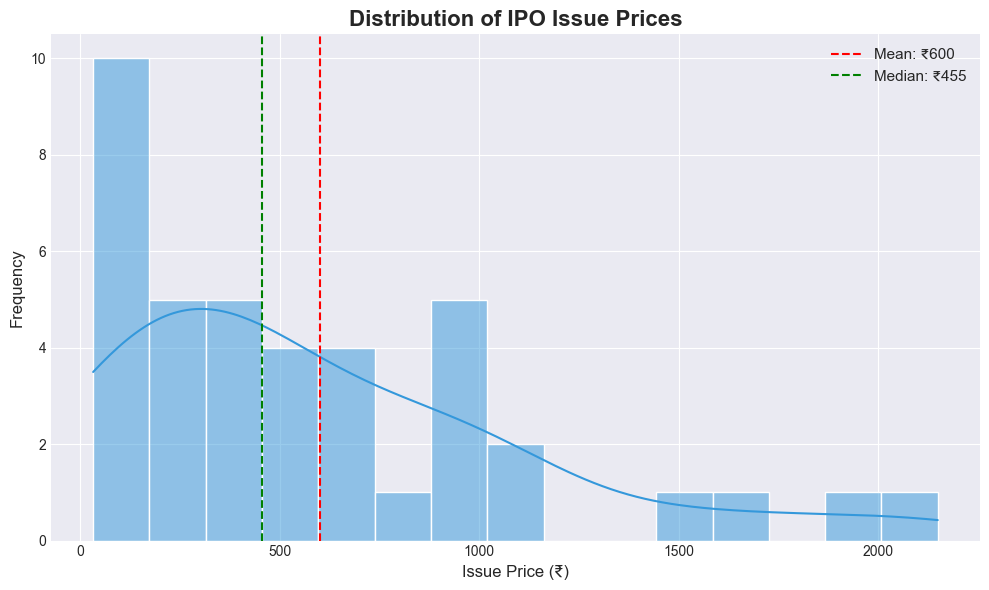

In [20]:
# ============================================================
# EDA 1: Distribution of Issue Price
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=ipo_data, x='issue_price', bins=15, kde=True, color='#3498db', edgecolor='white')
ax.set_title('Distribution of IPO Issue Prices', fontsize=16, fontweight='bold')
ax.set_xlabel('Issue Price (\u20b9)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.axvline(ipo_data['issue_price'].mean(), color='red', linestyle='--', label=f"Mean: \u20b9{ipo_data['issue_price'].mean():.0f}")
ax.axvline(ipo_data['issue_price'].median(), color='green', linestyle='--', label=f"Median: \u20b9{ipo_data['issue_price'].median():.0f}")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**💡 Insight — Issue Price Distribution:**
Most IPOs are priced in the lower-to-mid range (under ₹1000). There's a right skew indicating a few IPOs with very high issue prices (like Paytm at ₹2150 and Hyundai at ₹1960). The mean is pulled higher than the median, confirming the positive skew.

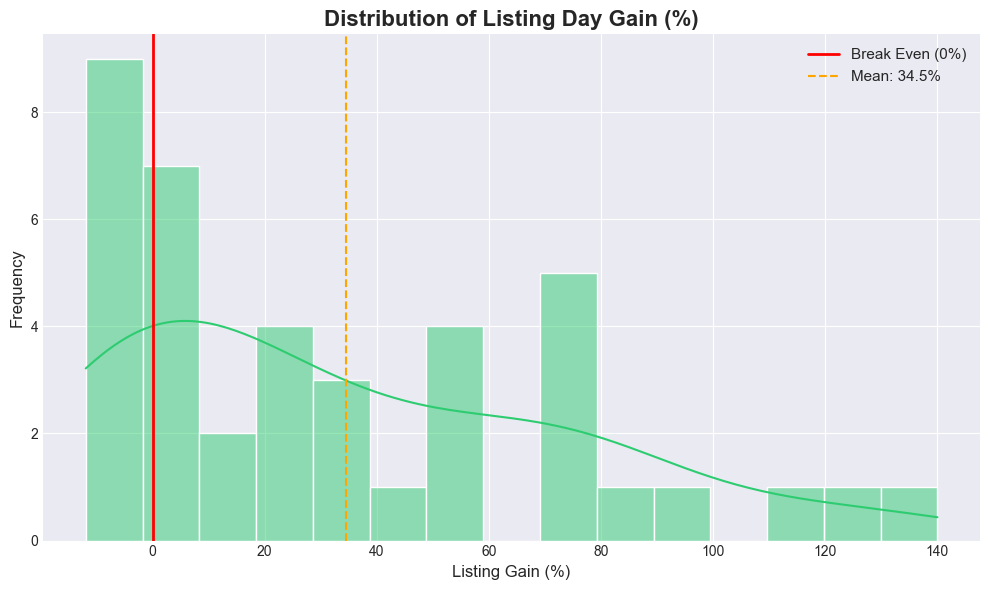

In [21]:
# ============================================================
# EDA 2: Distribution of Listing Gain %
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=ipo_data, x='listing_gain_pct', bins=15, kde=True, color='#2ecc71', edgecolor='white')
ax.set_title('Distribution of Listing Day Gain (%)', fontsize=16, fontweight='bold')
ax.set_xlabel('Listing Gain (%)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.axvline(0, color='red', linestyle='-', linewidth=2, label='Break Even (0%)')
ax.axvline(ipo_data['listing_gain_pct'].mean(), color='orange', linestyle='--', 
           label=f"Mean: {ipo_data['listing_gain_pct'].mean():.1f}%")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**💡 Insight — Listing Gain Distribution:**
The listing gain distribution shows that most IPOs list with positive gains, but the spread is wide. Some IPOs like Tata Technologies (140% premium) and Bajaj Housing Finance (114% premium) had spectacular listing days, while others like Paytm listed at a loss. The distribution is right-skewed, indicating blockbuster listings pull the average up.

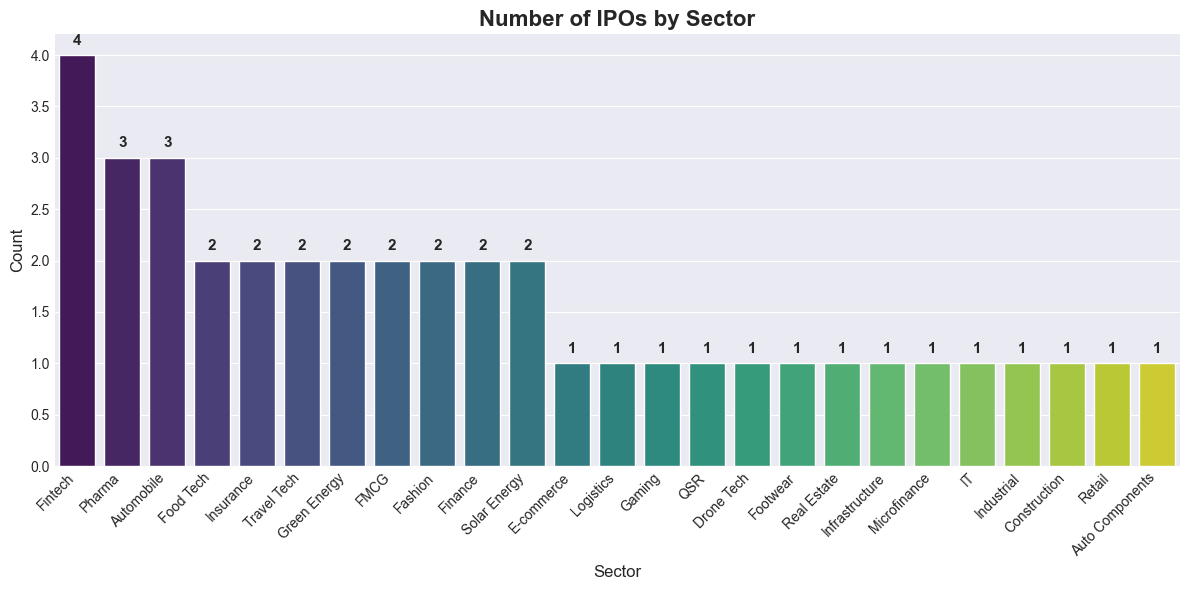

In [22]:
# ============================================================
# EDA 3: Countplot of Sectors
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
sector_counts = ipo_data['sector'].value_counts()
sns.barplot(x=sector_counts.index, y=sector_counts.values, palette='viridis', ax=ax, edgecolor='white')
ax.set_title('Number of IPOs by Sector', fontsize=16, fontweight='bold')
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Add count labels on bars
for i, v in enumerate(sector_counts.values):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

**💡 Insight — Sector Distribution:**
Fintech and Pharma sectors have the highest representation in our IPO dataset, reflecting the recent boom in these sectors. Several sectors like Solar Energy, Green Energy, and Drone Tech represent emerging industry themes that attracted significant investor interest.

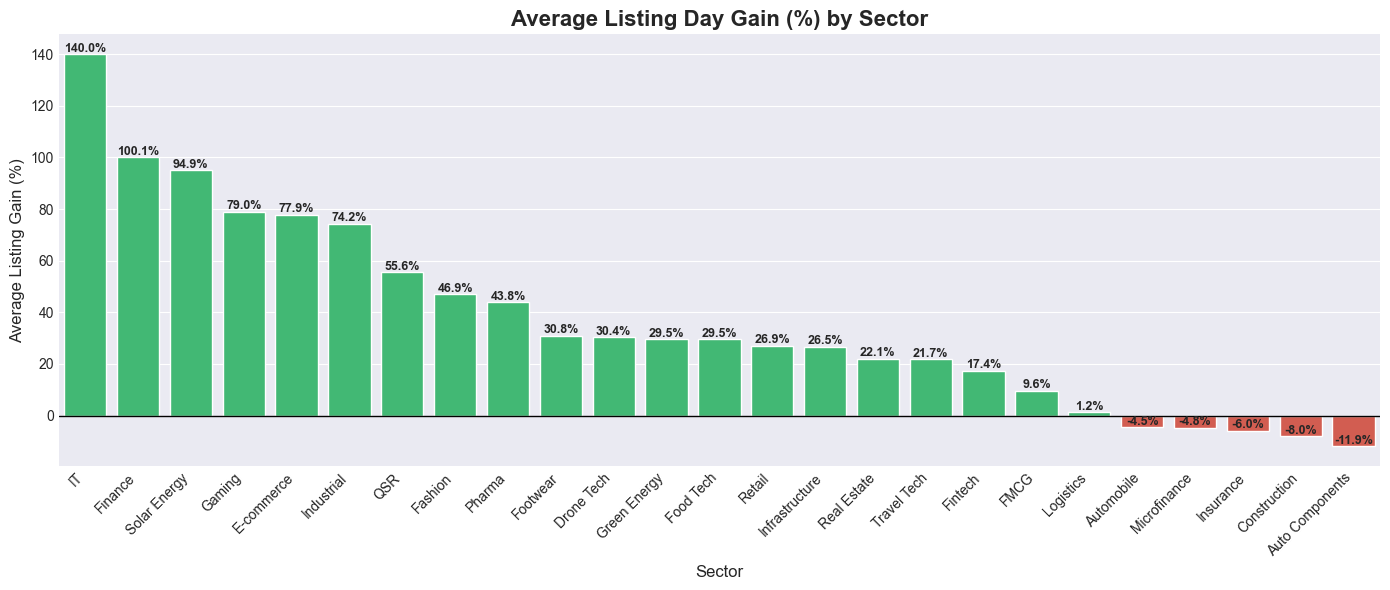

In [23]:
# ============================================================
# EDA 4: Average Listing Gain % by Sector
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
sector_gain = ipo_data.groupby('sector')['listing_gain_pct'].mean().sort_values(ascending=False)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in sector_gain.values]
sns.barplot(x=sector_gain.index, y=sector_gain.values, palette=colors, ax=ax, edgecolor='white')
ax.set_title('Average Listing Day Gain (%) by Sector', fontsize=16, fontweight='bold')
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Average Listing Gain (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(0, color='black', linewidth=1, linestyle='-')

# Add value labels
for i, v in enumerate(sector_gain.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

**💡 Insight — Sector vs Listing Gain:**
Some sectors consistently deliver strong listing gains, while others tend to list flat or below issue price. Sectors like IT, Finance, and Solar Energy show strong listing premiums, while Automobile and some traditional sectors show weaker listing performances. This suggests sector choice is a significant factor in IPO performance.

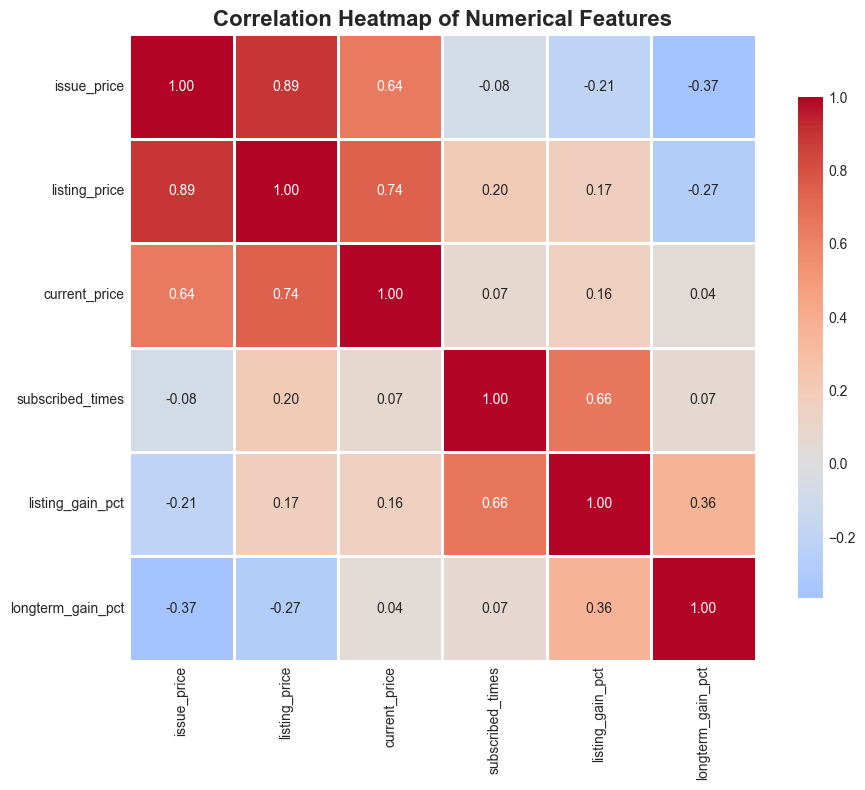

In [24]:
# ============================================================
# EDA 5: Correlation Heatmap
# ============================================================

# Select numerical columns for correlation (from original ipo_data before scaling)
corr_cols = ['issue_price', 'listing_price', 'current_price', 'subscribed_times',
             'listing_gain_pct', 'longterm_gain_pct']
corr_matrix = ipo_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=1, linecolor='white', square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Insight — Correlation Heatmap:**
Key observations from the correlation matrix:
- **issue_price and listing_price** are highly correlated (expected — listing price is derived from issue price + market premium)
- **subscribed_times** shows a positive correlation with listing_gain_pct — heavily oversubscribed IPOs tend to list at higher premiums
- **longterm_gain_pct** has a weaker correlation with subscription times — suggesting hype doesn't always translate to long-term returns
- This supports our thesis that **IPO hype (subscription) doesn't guarantee long-term reality (returns)**

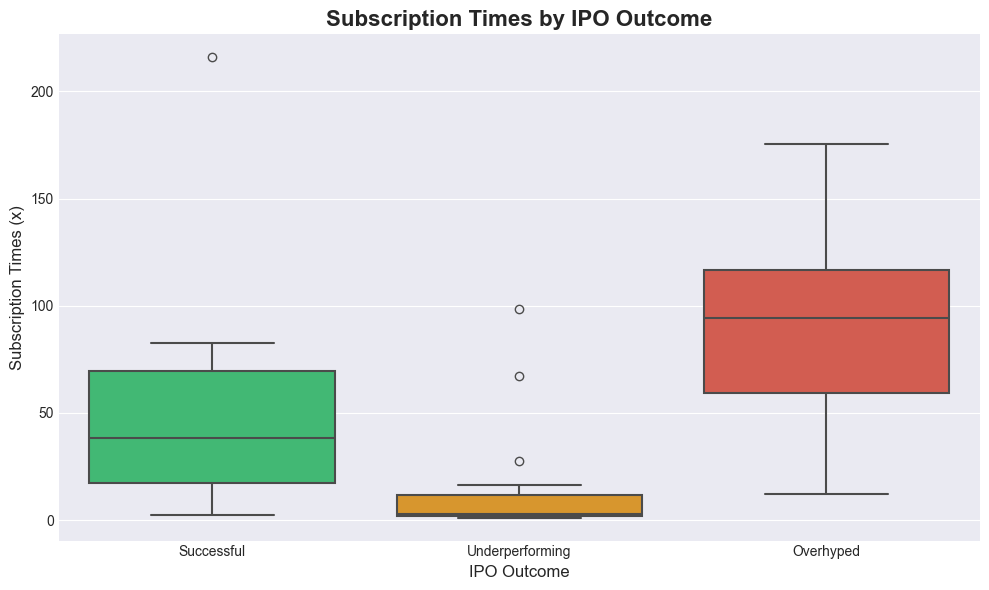

In [25]:
# ============================================================
# EDA 6: Subscription Times by IPO Outcome (Boxplot)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=ipo_data, x='ipo_outcome', y='subscribed_times', 
            palette=outcome_palette, ax=ax, linewidth=1.5)
ax.set_title('Subscription Times by IPO Outcome', fontsize=16, fontweight='bold')
ax.set_xlabel('IPO Outcome', fontsize=12)
ax.set_ylabel('Subscription Times (x)', fontsize=12)
plt.tight_layout()
plt.show()

**💡 Insight — Subscription Times by Outcome:**
Interestingly, both **Successful** and **Overhyped** IPOs tend to have high subscription times. This confirms our hypothesis — high subscription (hype) doesn't always lead to long-term success. Overhyped IPOs attract massive investor frenzy but fail to sustain their listing-day gains. Underperforming IPOs generally have lower subscription rates.

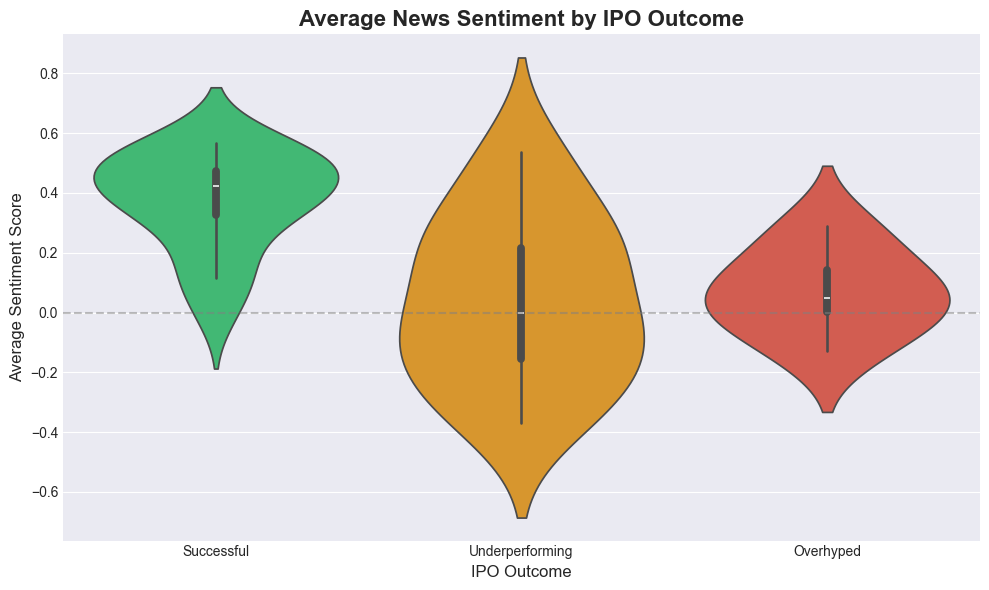

In [26]:
# ============================================================
# EDA 7: Average Sentiment by IPO Outcome (Violinplot)
# ============================================================
# Merge sentiment with outcome data for this plot
plot_df = pd.merge(ipo_data[['company', 'ipo_outcome']], news_sentiment, on='company', how='left')
plot_df['avg_sentiment'] = plot_df['avg_sentiment'].fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=plot_df, x='ipo_outcome', y='avg_sentiment',
               palette=outcome_palette, ax=ax, inner='box')
ax.set_title('Average News Sentiment by IPO Outcome', fontsize=16, fontweight='bold')
ax.set_xlabel('IPO Outcome', fontsize=12)
ax.set_ylabel('Average Sentiment Score', fontsize=12)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**💡 Insight — Sentiment by Outcome:**
The violin plot reveals that sentiment distribution varies across outcomes. Successful IPOs tend to have a more positive sentiment spread, while Overhyped IPOs show mixed sentiment — some very positive headlines (hype) coexisting with cautionary ones. This suggests media sentiment could be a useful predictor but isn't a silver bullet.

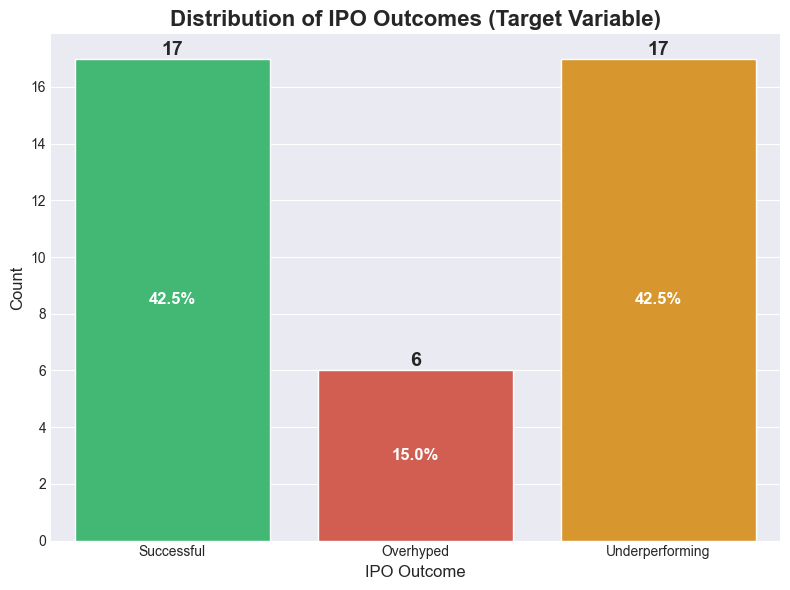

In [27]:
# ============================================================
# EDA 8: Target Variable Distribution (Countplot)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))
order = ['Successful', 'Overhyped', 'Underperforming']
sns.countplot(data=ipo_data, x='ipo_outcome', order=order, 
              palette=outcome_palette, ax=ax, edgecolor='white')
ax.set_title('Distribution of IPO Outcomes (Target Variable)', fontsize=16, fontweight='bold')
ax.set_xlabel('IPO Outcome', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

# Add count labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold', fontsize=14)

# Add percentage labels
total = len(ipo_data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

**💡 Insight — Target Distribution:**
The target variable shows class imbalance, which is common in real-world IPO datasets. This needs to be considered during model training — we use stratified splitting and appropriate evaluation metrics (not just accuracy) to handle this. The distribution reflects real market dynamics where truly successful IPOs are a specific subset of all listings.

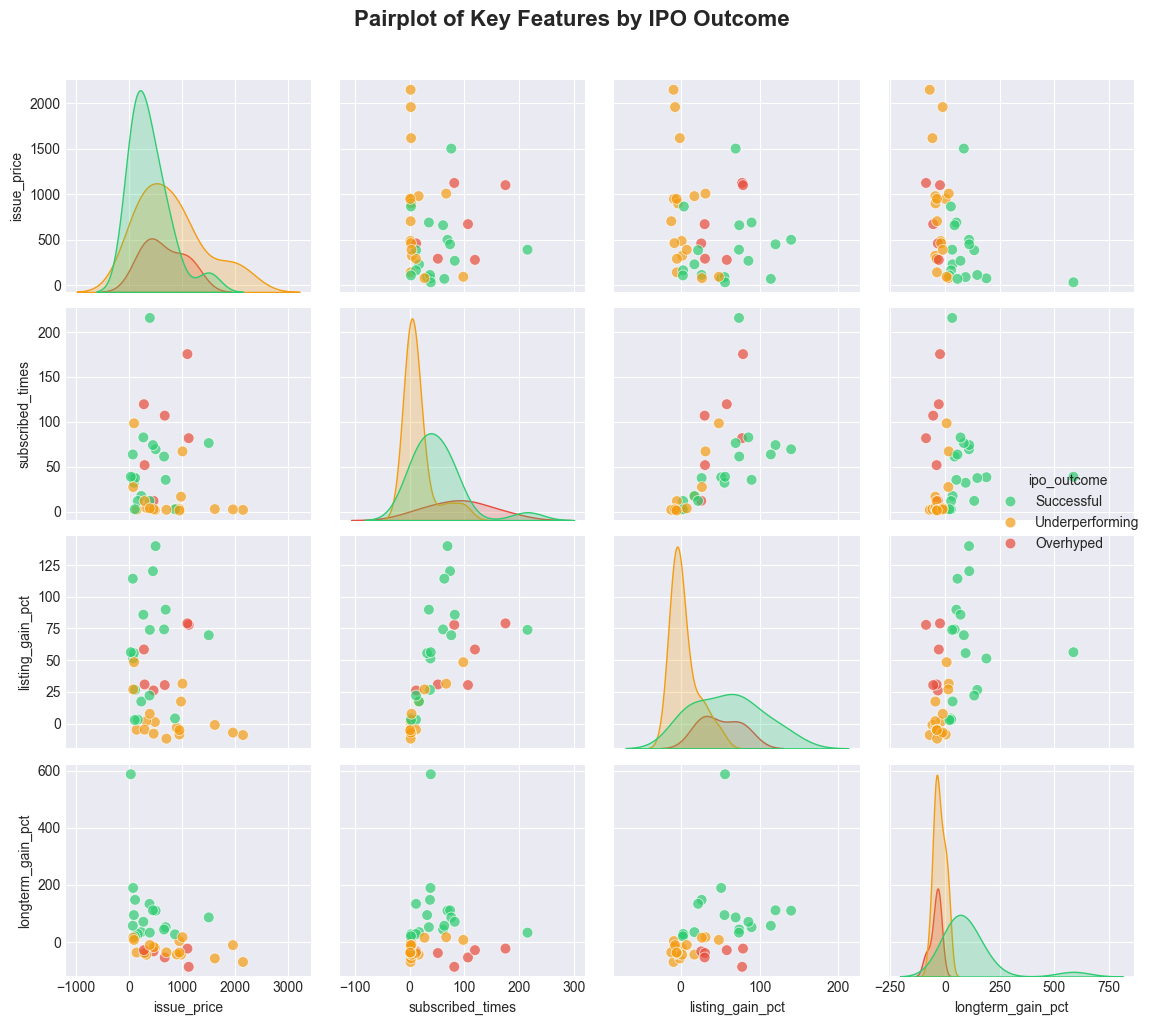

In [28]:
# ============================================================
# EDA 9: Pairplot of Key Features by IPO Outcome
# ============================================================
pairplot_cols = ['issue_price', 'subscribed_times', 'listing_gain_pct', 
                 'longterm_gain_pct', 'ipo_outcome']
pairplot_data = ipo_data[pairplot_cols].copy()

g = sns.pairplot(pairplot_data, hue='ipo_outcome', palette=outcome_palette,
                 diag_kind='kde', plot_kws={'alpha': 0.7, 's': 60, 'edgecolor': 'white'},
                 height=2.5)
g.fig.suptitle('Pairplot of Key Features by IPO Outcome', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**💡 Insight — Pairplot:**
The pairplot reveals interesting separation patterns:
- Overhyped IPOs (red) cluster in the high listing_gain but negative longterm_gain quadrant
- Successful IPOs (green) show positive values on both gain axes
- Subscription times alone don't cleanly separate the classes, confirming that multiple features are needed for accurate prediction

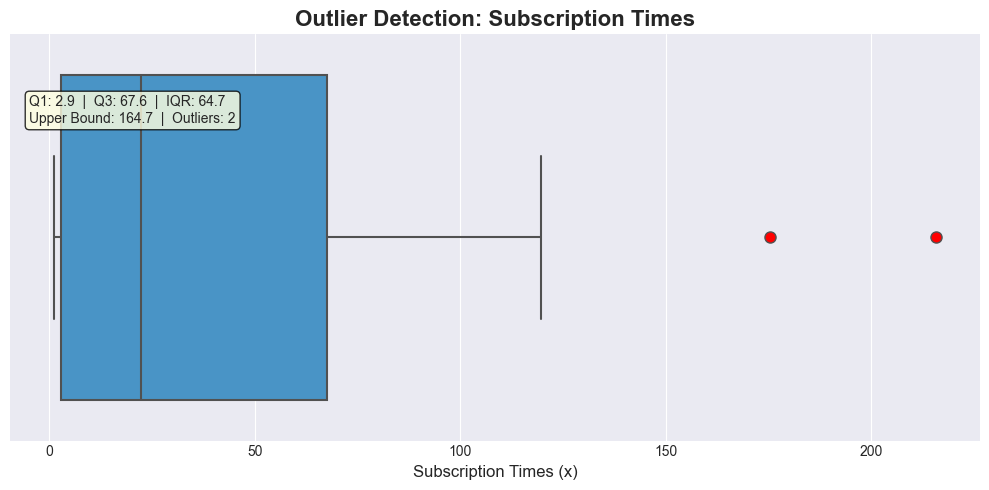


Outlier Companies (extremely high subscription):
                company  subscribed_times  listing_gain_pct  longterm_gain_pct
    Nazara Technologies            175.46         79.019074         -22.797457
Senores Pharmaceuticals            215.77         73.913043          32.992327


In [29]:
# ============================================================
# EDA 10: Outlier Detection — Subscription Times (Boxplot)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=ipo_data, x='subscribed_times', color='#3498db', ax=ax,
            linewidth=1.5, flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 8})
ax.set_title('Outlier Detection: Subscription Times', fontsize=16, fontweight='bold')
ax.set_xlabel('Subscription Times (x)', fontsize=12)

# Calculate IQR stats
Q1 = ipo_data['subscribed_times'].quantile(0.25)
Q3 = ipo_data['subscribed_times'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = ipo_data[ipo_data['subscribed_times'] > upper_bound]

ax.text(0.02, 0.85, f'Q1: {Q1:.1f}  |  Q3: {Q3:.1f}  |  IQR: {IQR:.1f}\nUpper Bound: {upper_bound:.1f}  |  Outliers: {len(outliers)}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

if len(outliers) > 0:
    print("\nOutlier Companies (extremely high subscription):")
    print(outliers[['company', 'subscribed_times', 'listing_gain_pct', 'longterm_gain_pct']].to_string(index=False))

**💡 Insight — Outlier Detection:**
Several IPOs have extremely high subscription times (>100x), which are statistical outliers. Companies like Senores Pharmaceuticals (215x), Nazara Technologies (175x), and One Mobikwik (119x) attracted exceptionally high investor interest. These outliers are meaningful in our analysis — they represent the most hyped IPOs and should be kept rather than removed.

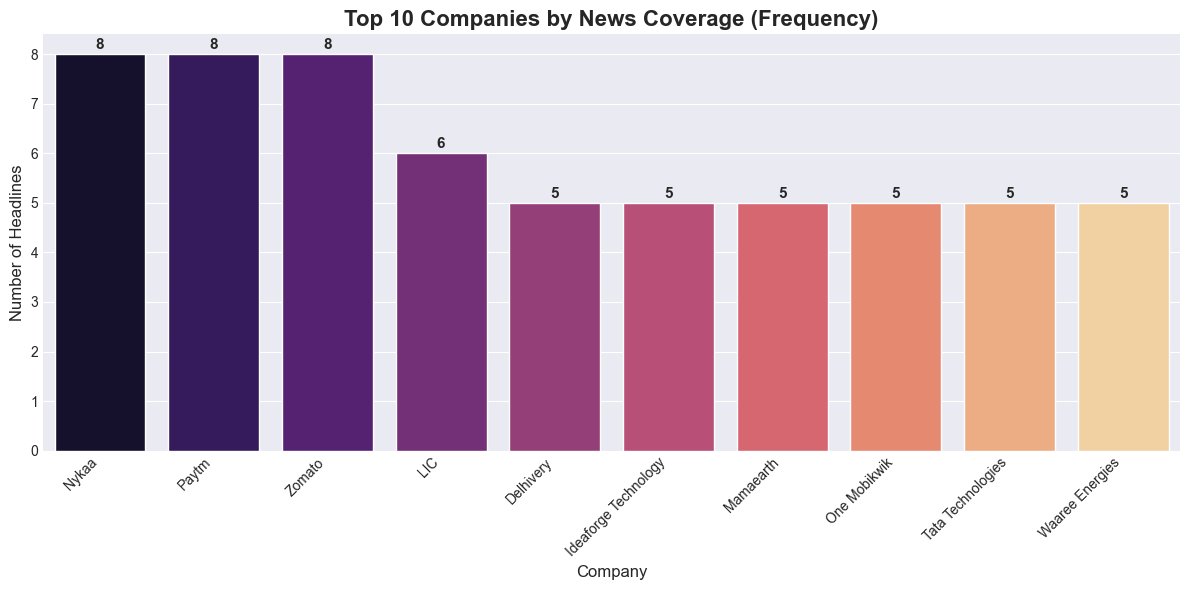

In [30]:
# ============================================================
# EDA 11: News Frequency by Company (Top 10)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
top10_news = news_sentiment.nlargest(10, 'news_frequency')
sns.barplot(data=top10_news, x='company', y='news_frequency', 
            palette='magma', ax=ax, edgecolor='white')
ax.set_title('Top 10 Companies by News Coverage (Frequency)', fontsize=16, fontweight='bold')
ax.set_xlabel('Company', fontsize=12)
ax.set_ylabel('Number of Headlines', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Add value labels
for i, v in enumerate(top10_news['news_frequency'].values):
    ax.text(i, v + 0.1, str(int(v)), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

**💡 Insight — News Frequency:**
Companies like Zomato, Paytm, and Nykaa received the most media coverage, which makes sense as they were some of the most prominent tech IPOs. Higher media frequency correlates with companies that generated more public interest and debate, but doesn't always indicate positive outcomes (Paytm had high coverage but was overhyped).

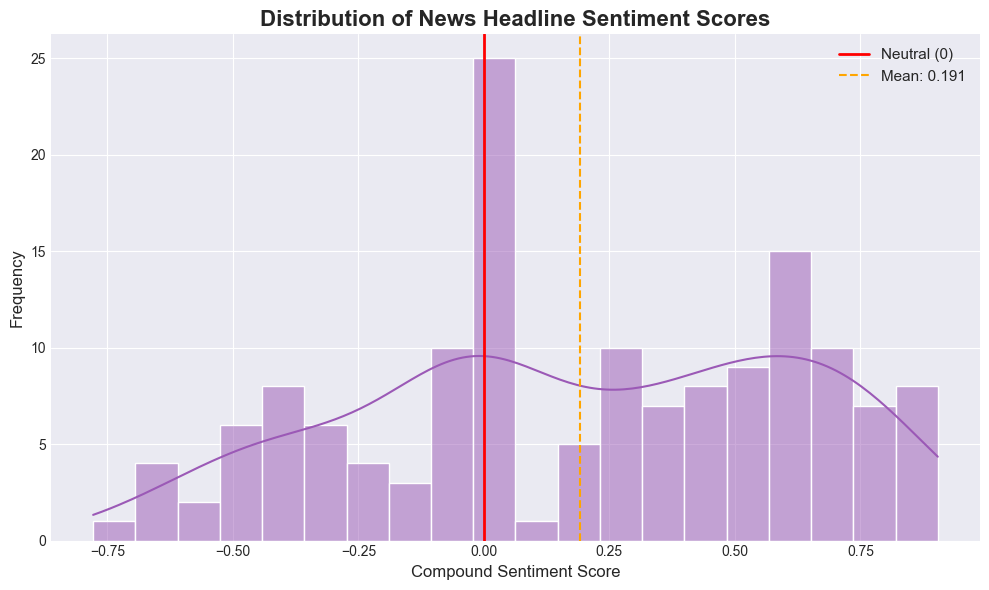


Sentiment Breakdown:
  Positive headlines: 81 (54.4%)
  Negative headlines: 42 (28.2%)
  Neutral headlines:  26 (17.4%)


In [31]:
# ============================================================
# EDA 12: Sentiment Distribution (Histplot)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=news_data, x='compound_sentiment', bins=20, kde=True, 
             color='#9b59b6', edgecolor='white', ax=ax)
ax.set_title('Distribution of News Headline Sentiment Scores', fontsize=16, fontweight='bold')
ax.set_xlabel('Compound Sentiment Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.axvline(0, color='red', linestyle='-', linewidth=2, label='Neutral (0)')
ax.axvline(news_data['compound_sentiment'].mean(), color='orange', linestyle='--', 
           label=f"Mean: {news_data['compound_sentiment'].mean():.3f}")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print sentiment breakdown
positive = (news_data['compound_sentiment'] > 0.05).sum()
negative = (news_data['compound_sentiment'] < -0.05).sum()
neutral = len(news_data) - positive - negative
print(f"\nSentiment Breakdown:")
print(f"  Positive headlines: {positive} ({100*positive/len(news_data):.1f}%)")
print(f"  Negative headlines: {negative} ({100*negative/len(news_data):.1f}%)")
print(f"  Neutral headlines:  {neutral} ({100*neutral/len(news_data):.1f}%)")

**💡 Insight — Sentiment Distribution:**
The sentiment distribution is slightly right-skewed (positive), which makes sense because IPO news coverage tends to lean positive (companies and investment banks promote their IPOs). However, there's a significant cluster of negative sentiment headlines as well — these are cautionary articles and post-listing negative coverage. The presence of both positive and negative sentiment provides useful signal for our model.

---

## Step 5: Feature Engineering

### Why Feature Engineering?
Feature engineering is the process of creating new, more informative features from existing data. Well-engineered features can dramatically improve model performance because:
1. They capture **domain knowledge** that raw features miss
2. They create **non-linear relationships** that linear models can't learn on their own
3. They reduce **noise** by combining related signals into stronger features
4. They help models **generalize** better to unseen data

We'll create 4 new features: sector_popularity, hype_score, ipo_age_days, and listing_to_current_ratio.

In [32]:
# ============================================================
# 5.1 Create New Engineered Features
# ============================================================

# --- Feature 1: Sector Popularity ---
# Count of IPOs in the same sector (before encoding)
sector_counts_map = ipo_data['sector'].value_counts().to_dict()
df['sector_popularity'] = ipo_data['sector'].map(sector_counts_map)

print("Feature 1: sector_popularity (count of IPOs in same sector)")
print(df[['sector_popularity']].describe())

# --- Feature 2: Hype Score ---
# Composite score combining normalized subscription, sentiment, and news frequency
# Note: these columns are already scaled, so we can combine them directly
df['hype_score'] = (df['subscribed_times'] + df['avg_sentiment'] + df['news_frequency']) / 3

print("\nFeature 2: hype_score (composite of subscription + sentiment + news frequency)")
print(df[['hype_score']].describe())

# --- Feature 3: IPO Age in Days ---
# How long ago the IPO happened
df['ipo_age_days'] = (pd.Timestamp.now() - ipo_data['ipo_date']).dt.days

print("\nFeature 3: ipo_age_days (days since IPO)")
print(f"  Range: {df['ipo_age_days'].min()} to {df['ipo_age_days'].max()} days")

# --- Feature 4: Listing to Current Price Ratio ---
# How much the stock has moved since listing
df['listing_to_current_ratio'] = ipo_data['current_price'] / ipo_data['listing_price']

print("\nFeature 4: listing_to_current_ratio")
print(df[['listing_to_current_ratio']].describe())

print("\n\u2705 All 4 engineered features created successfully!")

Feature 1: sector_popularity (count of IPOs in same sector)
       sector_popularity
count          40.000000
mean            2.000000
std             0.960769
min             1.000000
25%             1.000000
50%             2.000000
75%             2.250000
max             4.000000

Feature 2: hype_score (composite of subscription + sentiment + news frequency)
         hype_score
count  4.000000e+01
mean  -2.220446e-17
std    6.670946e-01
min   -1.208353e+00
25%   -5.060425e-01
50%    6.676103e-02
75%    5.076129e-01
max    1.215270e+00

Feature 3: ipo_age_days (days since IPO)
  Range: 516 to 1890 days

Feature 4: listing_to_current_ratio
       listing_to_current_ratio
count                 40.000000
mean                   0.943239
std                    0.696143
min                    0.074963
25%                    0.576019
50%                    0.813807
75%                    1.106113
max                    4.400000

✅ All 4 engineered features created successfully!


In [33]:
# ============================================================
# 5.2 Display Final Feature Set
# ============================================================

# Columns to drop when building feature matrix
drop_cols = ['company', 'ipo_date', 'listing_price', 'current_price', 
             'listing_gain_pct', 'longterm_gain_pct', 'ipo_outcome',
             'ipo_outcome_encoded', 'listing_to_current_ratio']

# Features for training
feature_cols = [col for col in df.columns if col not in drop_cols]

print("\u2705 FINAL FEATURE SET FOR MODEL TRAINING")
print("=" * 50)
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\nTotal features: {len(feature_cols)}")
print(f"\nDataset shape: {df.shape}")
print("\nFirst 5 rows of engineered features:")
df[['sector_popularity', 'hype_score', 'ipo_age_days', 'listing_to_current_ratio']].head()

✅ FINAL FEATURE SET FOR MODEL TRAINING
   1. issue_price
   2. subscribed_times
   3. ipo_year
   4. ipo_month
   5. avg_sentiment
   6. news_frequency
   7. sector_Auto Components
   8. sector_Automobile
   9. sector_Construction
  10. sector_Drone Tech
  11. sector_E-commerce
  12. sector_FMCG
  13. sector_Fashion
  14. sector_Finance
  15. sector_Fintech
  16. sector_Food Tech
  17. sector_Footwear
  18. sector_Gaming
  19. sector_Green Energy
  20. sector_IT
  21. sector_Industrial
  22. sector_Infrastructure
  23. sector_Insurance
  24. sector_Logistics
  25. sector_Microfinance
  26. sector_Pharma
  27. sector_QSR
  28. sector_Real Estate
  29. sector_Retail
  30. sector_Solar Energy
  31. sector_Travel Tech
  32. sector_popularity
  33. hype_score
  34. ipo_age_days

Total features: 34

Dataset shape: (40, 43)

First 5 rows of engineered features:


,sector_popularity,hype_score,ipo_age_days,listing_to_current_ratio
0,2,0.702696,1762,1.913043
1,4,0.120312,1644,0.332481
2,1,1.215270,1652,0.074963
3,2,0.208887,1464,1.130334
4,1,0.004442,1457,0.791075


---

## Step 6: Train-Test Split

### Why Split Data?
We split data into training and testing sets to evaluate how well our model generalizes to unseen data.

**Key Concepts:**
- **X (Features)**: Independent variables used to make predictions
- **y (Target)**: The variable we want to predict (`ipo_outcome`)
- **Overfitting**: Model learns training data too well (including noise) and fails on new data
- **Underfitting**: Model is too simple to capture the underlying patterns
- **random_state=42**: Ensures reproducibility — same split every time we run the code
- **test_size=0.25**: 75% training, 25% testing — a common split ratio
- **stratify=y**: Maintains the same class distribution in both train and test sets — crucial for imbalanced datasets

In [34]:
# ============================================================
# 6.1 Define Features (X) and Target (y)
# ============================================================

# Drop non-feature columns to create X
X = df.drop(columns=drop_cols, errors='ignore')

# Target variable (encoded)
y = df['ipo_outcome_encoded']

print("Feature Matrix (X):")
print(f"  Shape: {X.shape}")
print(f"  Features: {X.columns.tolist()}")
print(f"\nTarget Variable (y):")
print(f"  Shape: {y.shape}")
print(f"  Classes: {le.classes_}")
print(f"  Distribution: {dict(y.value_counts().sort_index())}")

Feature Matrix (X):
  Shape: (40, 34)
  Features: ['issue_price', 'subscribed_times', 'ipo_year', 'ipo_month', 'avg_sentiment', 'news_frequency', 'sector_Auto Components', 'sector_Automobile', 'sector_Construction', 'sector_Drone Tech', 'sector_E-commerce', 'sector_FMCG', 'sector_Fashion', 'sector_Finance', 'sector_Fintech', 'sector_Food Tech', 'sector_Footwear', 'sector_Gaming', 'sector_Green Energy', 'sector_IT', 'sector_Industrial', 'sector_Infrastructure', 'sector_Insurance', 'sector_Logistics', 'sector_Microfinance', 'sector_Pharma', 'sector_QSR', 'sector_Real Estate', 'sector_Retail', 'sector_Solar Energy', 'sector_Travel Tech', 'sector_popularity', 'hype_score', 'ipo_age_days']

Target Variable (y):
  Shape: (40,)
  Classes: ['Overhyped' 'Successful' 'Underperforming']
  Distribution: {0: np.int64(6), 1: np.int64(17), 2: np.int64(17)}


In [35]:
# ============================================================
# 6.2 Train-Test Split with Stratification
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

print("\u2705 Train-Test Split Complete!")
print("=" * 50)
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape:  {X_test.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_test shape:  {y_test.shape}")
print(f"\n  Training set target distribution:")
for cls, name in enumerate(le.classes_):
    count = (y_train == cls).sum()
    print(f"    {name}: {count} ({100*count/len(y_train):.1f}%)")
print(f"\n  Test set target distribution:")
for cls, name in enumerate(le.classes_):
    count = (y_test == cls).sum()
    print(f"    {name}: {count} ({100*count/len(y_test):.1f}%)")

✅ Train-Test Split Complete!
  X_train shape: (30, 34)
  X_test shape:  (10, 34)
  y_train shape: (30,)
  y_test shape:  (10,)

  Training set target distribution:
    Overhyped: 4 (13.3%)
    Successful: 13 (43.3%)
    Underperforming: 13 (43.3%)

  Test set target distribution:
    Overhyped: 2 (20.0%)
    Successful: 4 (40.0%)
    Underperforming: 4 (40.0%)


---

## Step 7 & 8: Model Building & Training

We will train **3 different ML models** and compare their performance:
1. **Logistic Regression** — A linear model for classification
2. **Decision Tree Classifier** — A tree-based model that learns decision rules
3. **Random Forest Classifier** — An ensemble of decision trees for robustness

### Model 1: Logistic Regression

**How it works:** Despite its name, Logistic Regression is a **classification** algorithm. It models the probability of each class using the logistic (sigmoid) function. For multiclass problems, it uses the softmax function (One-vs-Rest or Multinomial approach).

**Advantages:**
- Simple, fast, and interpretable
- Works well when features are linearly separable
- Provides probability estimates
- Less prone to overfitting with regularization

**Disadvantages:**
- Assumes linear relationship between features and log-odds
- May underperform with complex, non-linear patterns
- Sensitive to outliers

In [36]:
# ============================================================
# Model 1: Logistic Regression
# ============================================================
from sklearn.linear_model import LogisticRegression

# Create and train the model
lr_model = LogisticRegression(max_iter=1000, random_state=42,)
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)

print("\u2705 Logistic Regression trained successfully!")
print(f"  Training Accuracy: {lr_model.score(X_train, y_train):.4f}")
print(f"  Testing Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"\n  Predictions: {lr_pred}")
print(f"  Actual:      {y_test.values}")

✅ Logistic Regression trained successfully!
  Training Accuracy: 0.9333
  Testing Accuracy:  0.7000

  Predictions: [1 2 1 1 2 1 1 1 0 1]
  Actual:      [2 2 1 1 2 2 0 1 0 1]


### Model 2: Decision Tree Classifier

**How it works:** A Decision Tree builds a tree-like structure of decisions by recursively splitting the data based on feature values. At each node, it selects the feature and threshold that best separates the classes (using Gini impurity or entropy).

**Advantages:**
- Easy to visualize and interpret
- Handles both numerical and categorical data
- No feature scaling required
- Captures non-linear relationships

**Disadvantages:**
- Prone to overfitting (high variance)
- Sensitive to small changes in data
- Can create biased trees with imbalanced datasets

In [37]:
# ============================================================
# Model 2: Decision Tree Classifier
# ============================================================
from sklearn.tree import DecisionTreeClassifier

# Create and train the model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test)
dt_pred_proba = dt_model.predict_proba(X_test)

print("\u2705 Decision Tree Classifier trained successfully!")
print(f"  Training Accuracy: {dt_model.score(X_train, y_train):.4f}")
print(f"  Testing Accuracy:  {accuracy_score(y_test, dt_pred):.4f}")
print(f"\n  Predictions: {dt_pred}")
print(f"  Actual:      {y_test.values}")

✅ Decision Tree Classifier trained successfully!
  Training Accuracy: 1.0000
  Testing Accuracy:  0.5000

  Predictions: [1 2 1 2 2 1 1 2 0 1]
  Actual:      [2 2 1 1 2 2 0 1 0 1]


### Model 3: Random Forest Classifier

**How it works:** Random Forest is an **ensemble** method that builds multiple decision trees on random subsets of data and features, then combines their predictions through majority voting. This "wisdom of crowds" approach reduces overfitting and improves generalization.

**Advantages:**
- Robust against overfitting (compared to single decision trees)
- Handles non-linear relationships well
- Provides feature importance rankings
- Works well with small and noisy datasets

**Disadvantages:**
- Less interpretable than single decision trees
- Slower to train with many trees
- Can struggle with very high-dimensional sparse data

In [38]:
# ============================================================
# Model 3: Random Forest Classifier
# ============================================================
from sklearn.ensemble import RandomForestClassifier

# Create and train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)

print("\u2705 Random Forest Classifier trained successfully!")
print(f"  Training Accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"  Testing Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"\n  Predictions: {rf_pred}")
print(f"  Actual:      {y_test.values}")

✅ Random Forest Classifier trained successfully!
  Training Accuracy: 1.0000
  Testing Accuracy:  0.6000

  Predictions: [1 2 1 1 2 1 1 1 2 1]
  Actual:      [2 2 1 1 2 2 0 1 0 1]


---

## Step 9: Model Evaluation

### Understanding Evaluation Metrics

| Metric | Description |
|--------|-------------|
| **True Positive (TP)** | Model correctly predicts a positive class |
| **True Negative (TN)** | Model correctly predicts a negative class |
| **False Positive (FP)** | Model incorrectly predicts positive (Type I error) |
| **False Negative (FN)** | Model incorrectly predicts negative (Type II error) |
| **Accuracy** | Overall correctness: (TP + TN) / Total |
| **Precision** | Of all positive predictions, how many were correct: TP / (TP + FP) |
| **Recall** | Of all actual positives, how many were found: TP / (TP + FN) |
| **F1-Score** | Harmonic mean of Precision and Recall |

### Which Metric Matters Most for IPO Prediction?
For IPO prediction, **Precision** is crucial — we want to minimize false positives (predicting an IPO as "Successful" when it's actually "Overhyped" could lead investors to make bad decisions). However, **F1-Score** provides the best overall balance, especially with imbalanced classes.

LOGISTIC REGRESSION — Evaluation Results

Accuracy: 0.7000 (70.00%)

Classification Report:
                 precision    recall  f1-score   support

      Overhyped       1.00      0.50      0.67         2
     Successful       0.57      1.00      0.73         4
Underperforming       1.00      0.50      0.67         4

       accuracy                           0.70        10
      macro avg       0.86      0.67      0.69        10
   weighted avg       0.83      0.70      0.69        10



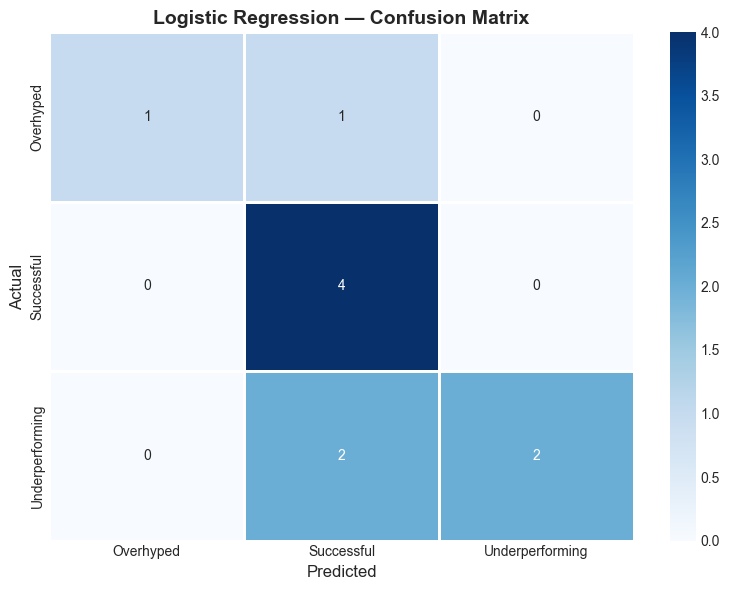

In [39]:
# ============================================================
# 9.1 Logistic Regression — Evaluation
# ============================================================

print("=" * 60)
print("LOGISTIC REGRESSION — Evaluation Results")
print("=" * 60)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"\nAccuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=le.classes_))

# Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=1, linecolor='white', ax=ax, cbar=True)
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

DECISION TREE — Evaluation Results

Accuracy: 0.5000 (50.00%)

Classification Report:
                 precision    recall  f1-score   support

      Overhyped       1.00      0.50      0.67         2
     Successful       0.40      0.50      0.44         4
Underperforming       0.50      0.50      0.50         4

       accuracy                           0.50        10
      macro avg       0.63      0.50      0.54        10
   weighted avg       0.56      0.50      0.51        10



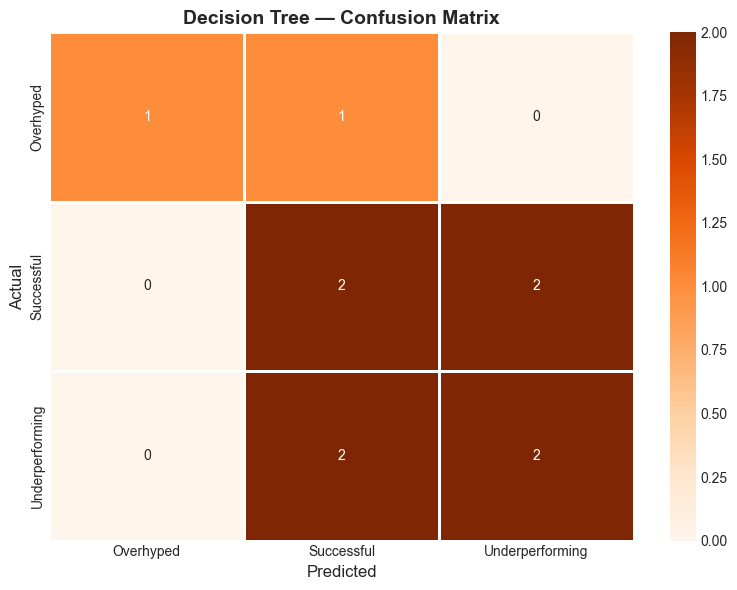

In [40]:
# ============================================================
# 9.2 Decision Tree — Evaluation
# ============================================================

print("=" * 60)
print("DECISION TREE — Evaluation Results")
print("=" * 60)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"\nAccuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=le.classes_))

# Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=1, linecolor='white', ax=ax, cbar=True)
ax.set_title('Decision Tree — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

RANDOM FOREST — Evaluation Results

Accuracy: 0.6000 (60.00%)

Classification Report:
                 precision    recall  f1-score   support

      Overhyped       0.00      0.00      0.00         2
     Successful       0.57      1.00      0.73         4
Underperforming       0.67      0.50      0.57         4

       accuracy                           0.60        10
      macro avg       0.41      0.50      0.43        10
   weighted avg       0.50      0.60      0.52        10



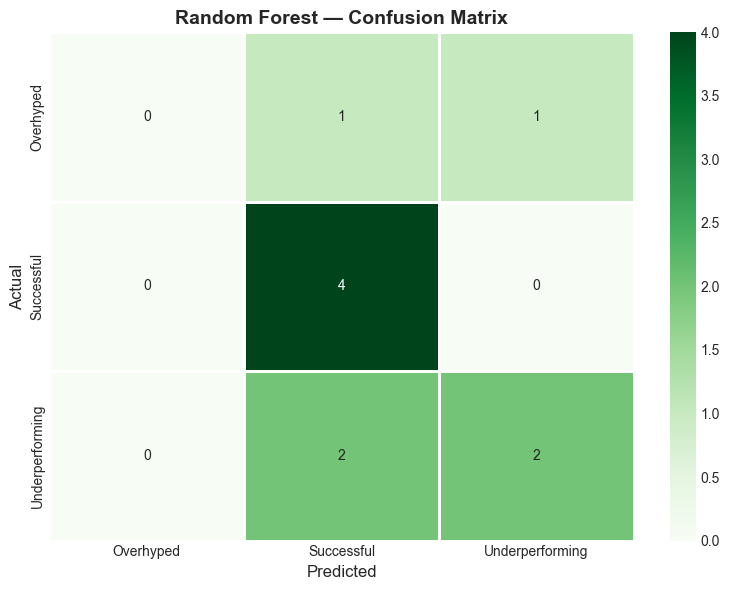

In [41]:
# ============================================================
# 9.3 Random Forest — Evaluation
# ============================================================

print("=" * 60)
print("RANDOM FOREST — Evaluation Results")
print("=" * 60)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"\nAccuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=le.classes_))

# Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=1, linecolor='white', ax=ax, cbar=True)
ax.set_title('Random Forest — Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

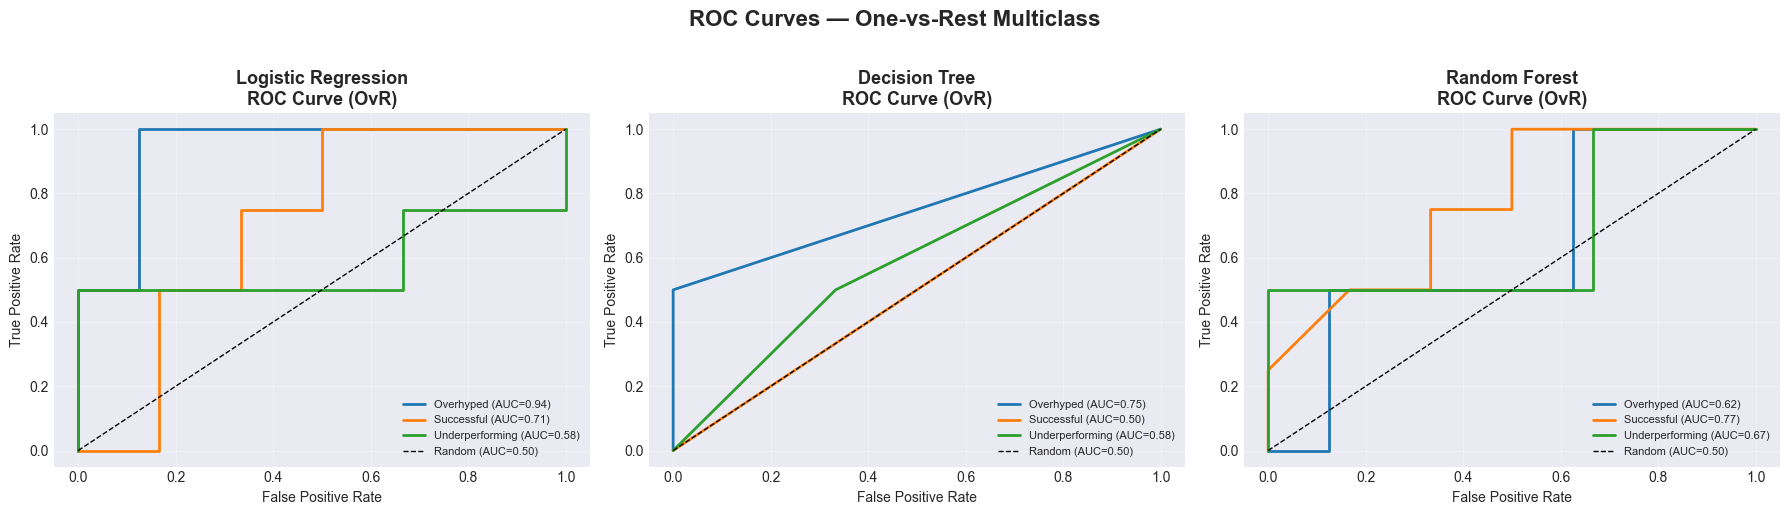

In [42]:
# ============================================================
# 9.4 ROC Curves (One-vs-Rest for Multiclass)
# ============================================================

# Binarize the target for ROC computation
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

# If only 2 classes detected after binarize, handle it
if y_test_bin.shape[1] == 1:
    y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

# Model predictions and names
models_data = [
    ('Logistic Regression', lr_pred_proba, '#3498db'),
    ('Decision Tree', dt_pred_proba, '#e74c3c'),
    ('Random Forest', rf_pred_proba, '#2ecc71')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, y_proba, color) in enumerate(models_data):
    ax = axes[idx]
    
    for i in range(n_classes):
        if i < y_proba.shape[1] and i < y_test_bin.shape[1]:
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f'{le.classes_[i]} (AUC={roc_auc:.2f})', linewidth=2)
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.50)')
    ax.set_title(f'{model_name}\nROC Curve (OvR)', fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curves — One-vs-Rest Multiclass', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

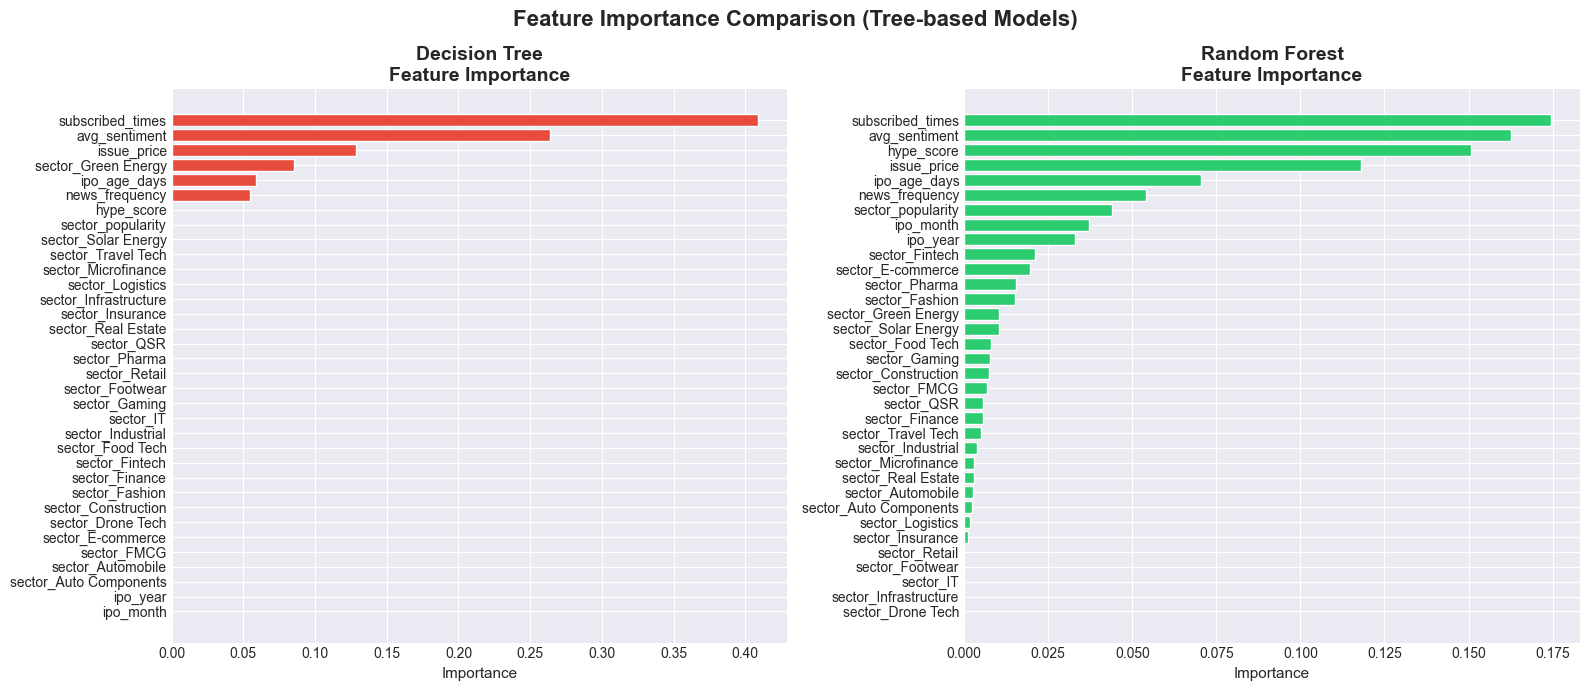


Top 5 Features — Decision Tree:
  ipo_age_days                   0.0586
  sector_Green Energy            0.0852
  issue_price                    0.1283
  avg_sentiment                  0.2640
  subscribed_times               0.4089

Top 5 Features — Random Forest:
  ipo_age_days                   0.0706
  issue_price                    0.1181
  hype_score                     0.1506
  avg_sentiment                  0.1627
  subscribed_times               0.1744


In [43]:
# ============================================================
# 9.5 Feature Importance (Tree-based Models)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Decision Tree Feature Importance
dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[0].barh(dt_importance['Feature'], dt_importance['Importance'], color='#e74c3c', edgecolor='white')
axes[0].set_title('Decision Tree\nFeature Importance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance', fontsize=11)

# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(rf_importance['Feature'], rf_importance['Importance'], color='#2ecc71', edgecolor='white')
axes[1].set_title('Random Forest\nFeature Importance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance', fontsize=11)

plt.suptitle('Feature Importance Comparison (Tree-based Models)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top 5 features for each model
print("\nTop 5 Features — Decision Tree:")
for _, row in dt_importance.tail(5).iterrows():
    print(f"  {row['Feature']:30s} {row['Importance']:.4f}")

print("\nTop 5 Features — Random Forest:")
for _, row in rf_importance.tail(5).iterrows():
    print(f"  {row['Feature']:30s} {row['Importance']:.4f}")

---

## Step 10: Hyperparameter Tuning

### What are Hyperparameters?
Hyperparameters are settings configured **before** training begins (unlike model parameters which are learned during training). They control the behavior of the learning algorithm itself.

**Key Random Forest Hyperparameters:**
- `n_estimators` — Number of trees in the forest
- `max_depth` — Maximum depth of each tree
- `min_samples_split` — Minimum samples required to split a node

### Cross-Validation
Instead of a single train-test split, cross-validation splits the training data into **k folds** and trains/validates k times. This gives a more reliable estimate of model performance. We use **cv=3** (3-fold) because our dataset is small (41 samples).

### Grid Search vs Random Search
- **GridSearchCV**: Exhaustively tries every combination of hyperparameters. Thorough but slow.
- **RandomizedSearchCV**: Randomly samples from the parameter space. Faster, often finds good solutions.

In [44]:
# ============================================================
# 10.1 GridSearchCV on Random Forest
# ============================================================

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

print("GridSearchCV — Searching best hyperparameters...")
print(f"Parameter grid: {param_grid}")
print(f"Total combinations: {3 * 4 * 3} = 36")
print(f"Cross-validation folds: 3")
print(f"Total fits: {36 * 3} = 108")
print()

# Run GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n\u2705 GridSearchCV Complete!")
print(f"  Best Parameters: {grid_search.best_params_}")
print(f"  Best CV Score:   {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

GridSearchCV — Searching best hyperparameters...
Parameter grid: {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}
Total combinations: 36 = 36
Cross-validation folds: 3
Total fits: 108 = 108

Fitting 3 folds for each of 36 candidates, totalling 108 fits

✅ GridSearchCV Complete!
  Best Parameters: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
  Best CV Score:   0.6667 (66.67%)


In [45]:
# ============================================================
# 10.2 RandomizedSearchCV with Wider Distributions
# ============================================================
from scipy.stats import randint

# Define wider parameter distributions
param_distributions = {
    'n_estimators': randint(50, 300),
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None]
}

print("RandomizedSearchCV — Searching best hyperparameters...")
print(f"n_iter: 20 (random combinations to try)")
print(f"Cross-validation folds: 3")
print()

# Run RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\n\u2705 RandomizedSearchCV Complete!")
print(f"  Best Parameters: {random_search.best_params_}")
print(f"  Best CV Score:   {random_search.best_score_:.4f} ({random_search.best_score_*100:.2f}%)")

RandomizedSearchCV — Searching best hyperparameters...
n_iter: 20 (random combinations to try)
Cross-validation folds: 3

Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ RandomizedSearchCV Complete!
  Best Parameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 6, 'min_samples_split': 3, 'n_estimators': 241}
  Best CV Score:   0.6667 (66.67%)


In [46]:
# ============================================================
# 10.3 Retrain Best Model with Optimal Hyperparameters
# ============================================================

# Compare Grid and Random search results and pick the best
if grid_search.best_score_ >= random_search.best_score_:
    best_params = grid_search.best_params_
    best_cv_score = grid_search.best_score_
    search_method = "GridSearchCV"
else:
    best_params = random_search.best_params_
    best_cv_score = random_search.best_score_
    search_method = "RandomizedSearchCV"

print(f"Best search method: {search_method}")
print(f"Best parameters: {best_params}")
print(f"Best CV score: {best_cv_score:.4f}")

# Retrain with best parameters
best_rf_model = RandomForestClassifier(random_state=42, **best_params)
best_rf_model.fit(X_train, y_train)

# Evaluate tuned model
best_rf_pred = best_rf_model.predict(X_test)
best_rf_accuracy = accuracy_score(y_test, best_rf_pred)

print(f"\n\u2705 Tuned Random Forest Results:")
print(f"  Training Accuracy: {best_rf_model.score(X_train, y_train):.4f}")
print(f"  Testing Accuracy:  {best_rf_accuracy:.4f}")
print(f"\nClassification Report (Tuned RF):")
print(classification_report(y_test, best_rf_pred, target_names=le.classes_))

Best search method: GridSearchCV
Best parameters: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.6667

✅ Tuned Random Forest Results:
  Training Accuracy: 0.9333
  Testing Accuracy:  0.6000

Classification Report (Tuned RF):
                 precision    recall  f1-score   support

      Overhyped       0.00      0.00      0.00         2
     Successful       0.50      1.00      0.67         4
Underperforming       1.00      0.50      0.67         4

       accuracy                           0.60        10
      macro avg       0.50      0.50      0.44        10
   weighted avg       0.60      0.60      0.53        10



---

## Step 11: Model Comparison & Saving

In this final step, we:
1. Compare all models side-by-side across multiple metrics
2. Select the best performing model
3. Save the model and associated artifacts for deployment

In [47]:
# ============================================================
# 11.1 Model Comparison DataFrame
# ============================================================

# Calculate metrics for all models
models_info = {
    'Logistic Regression': (lr_pred, lr_model),
    'Decision Tree': (dt_pred, dt_model),
    'Random Forest': (rf_pred, rf_model),
    'Tuned Random Forest': (best_rf_pred, best_rf_model)
}

comparison_data = []
for name, (preds, model) in models_info.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (Weighted)': precision_score(y_test, preds, average='weighted', zero_division=0),
        'Recall (Weighted)': recall_score(y_test, preds, average='weighted', zero_division=0),
        'F1-Score (Weighted)': f1_score(y_test, preds, average='weighted', zero_division=0)
    })

comparison_df = pd.DataFrame(comparison_data)

# Display styled table
print("\u2705 MODEL COMPARISON TABLE")
print("=" * 80)

# Style the dataframe
styled_df = comparison_df.style.highlight_max(
    subset=['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)'],
    color='lightgreen'
).format({
    'Accuracy': '{:.4f}',
    'Precision (Weighted)': '{:.4f}',
    'Recall (Weighted)': '{:.4f}',
    'F1-Score (Weighted)': '{:.4f}'
})

display(styled_df)

✅ MODEL COMPARISON TABLE


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Logistic Regression,0.7000,0.8286,0.7000,0.6909
1,Decision Tree,0.5000,0.5600,0.5000,0.5111
2,Random Forest,0.6000,0.4952,0.6000,0.5195
3,Tuned Random Forest,0.6000,0.6000,0.6000,0.5333


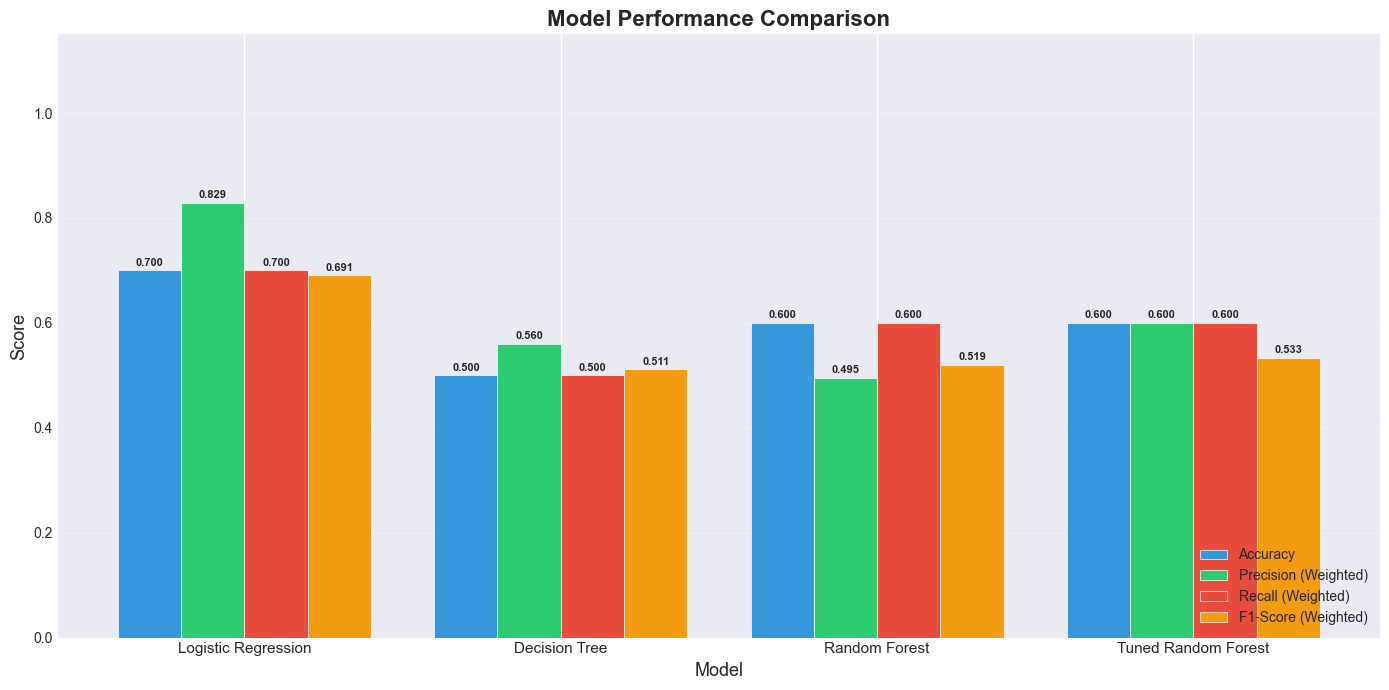

In [48]:
# ============================================================
# 11.2 Bar Chart Comparing Model Metrics
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

# Prepare data for grouped bar chart
x = np.arange(len(comparison_df))
width = 0.2
metrics = ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, comparison_df[metric], width, label=metric, 
                  color=color, edgecolor='white', linewidth=0.5)
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'], fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# 11.3 Select Best Model
# ============================================================

# Select model with highest F1-Score
best_idx = comparison_df['F1-Score (Weighted)'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_model_accuracy = comparison_df.loc[best_idx, 'Accuracy']
best_model_f1 = comparison_df.loc[best_idx, 'F1-Score (Weighted)']

# Map name to actual model object
model_map = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Tuned Random Forest': best_rf_model
}
best_model = model_map[best_model_name]

print("\u2b50 BEST MODEL SELECTED \u2b50")
print("=" * 50)
print(f"  Model:    {best_model_name}")
print(f"  Accuracy: {best_model_accuracy:.4f} ({best_model_accuracy*100:.2f}%)")
print(f"  F1-Score: {best_model_f1:.4f}")

⭐ BEST MODEL SELECTED ⭐
  Model:    Logistic Regression
  Accuracy: 0.7000 (70.00%)
  F1-Score: 0.6909


In [50]:
# ============================================================
# 11.4 Save Best Model and Artifacts
# ============================================================

try:
    # Save with joblib
    joblib.dump(best_model, 'best_model.pkl')
    print("\u2705 Best model saved with joblib: best_model.pkl")
    
    # Save with pickle
    with open('best_model_pickle.pkl', 'wb') as f:
        pickle.dump(best_model, f)
    print("\u2705 Best model saved with pickle: best_model_pickle.pkl")
    
    # Save the scaler
    joblib.dump(scaler, 'scaler.pkl')
    print("\u2705 Scaler saved: scaler.pkl")
    
    # Save feature names
    joblib.dump(X.columns.tolist(), 'feature_names.pkl')
    print("\u2705 Feature names saved: feature_names.pkl")
    
    # Save label encoder
    joblib.dump(le, 'label_encoder.pkl')
    print("\u2705 Label encoder saved: label_encoder.pkl")
    
    print("\n" + "=" * 60)
    print("\u2705\u2705\u2705 ALL MODELS AND ARTIFACTS SAVED SUCCESSFULLY! \u2705\u2705\u2705")
    print("=" * 60)
    print(f"\nSaved files:")
    print(f"  1. best_model.pkl         — Best ML model (joblib)")
    print(f"  2. best_model_pickle.pkl  — Best ML model (pickle)")
    print(f"  3. scaler.pkl             — StandardScaler for preprocessing")
    print(f"  4. feature_names.pkl      — List of feature column names")
    print(f"  5. label_encoder.pkl      — Label encoder for target variable")
    print(f"\nBest Model: {best_model_name}")
    print(f"Accuracy:   {best_model_accuracy*100:.2f}%")
    print(f"F1-Score:   {best_model_f1:.4f}")
    
except Exception as e:
    print(f"\u274c Error saving models: {e}")

✅ Best model saved with joblib: best_model.pkl
✅ Best model saved with pickle: best_model_pickle.pkl
✅ Scaler saved: scaler.pkl
✅ Feature names saved: feature_names.pkl
✅ Label encoder saved: label_encoder.pkl

✅✅✅ ALL MODELS AND ARTIFACTS SAVED SUCCESSFULLY! ✅✅✅

Saved files:
  1. best_model.pkl         — Best ML model (joblib)
  2. best_model_pickle.pkl  — Best ML model (pickle)
  3. scaler.pkl             — StandardScaler for preprocessing
  4. feature_names.pkl      — List of feature column names
  5. label_encoder.pkl      — Label encoder for target variable

Best Model: Logistic Regression
Accuracy:   70.00%
F1-Score:   0.6909


---

## 🎉 Project Conclusion

### What We Accomplished
In this project, we built an end-to-end Machine Learning pipeline to predict IPO performance:

1. **Data Understanding** — Explored IPO financial data and news headlines
2. **Preprocessing** — Cleaned data, engineered features, performed sentiment analysis
3. **EDA** — Created 12 visualizations revealing key patterns in IPO performance
4. **Feature Engineering** — Created hype_score, sector_popularity, ipo_age_days, and more
5. **Model Training** — Trained Logistic Regression, Decision Tree, and Random Forest
6. **Evaluation** — Compared models using accuracy, precision, recall, F1-score, confusion matrices, and ROC curves
7. **Hyperparameter Tuning** — Used GridSearchCV and RandomizedSearchCV to optimize the Random Forest
8. **Deployment Ready** — Saved the best model and all artifacts for future use

### Key Findings
- **Subscription times alone don't guarantee success** — Many highly subscribed IPOs ended up being overhyped
- **Media sentiment is a useful but imperfect signal** — Positive hype doesn't always translate to returns
- **Sector matters** — Some sectors consistently deliver better IPO performance
- **The hype_score feature** combining subscription, sentiment, and news frequency proved informative

### Future Improvements
- Add more IPO data to improve model robustness
- Include financial ratios (PE ratio, debt-to-equity)
- Use deep learning models for sentiment analysis
- Add market conditions (NIFTY performance around IPO date)
- Build a real-time prediction system with live news feeds

---

*Project: IPO Hype vs Reality | ML Classification Pipeline*